# Group Work Project 1

## Group: 8429
## Submitted by: Gaurav Sharma, Vikas Gautam, Miklos Lammel
## Date: 27/2/2025



In [1]:
!pip install tensorflow
!pip install scikeras
!pip install tensorflow-addons
!pip install pyts
!pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 8.3 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.2
    Uninstalling typeguard-4.4.2:
      Successfully uninstalled typeguard-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.8 MB/s eta 0:00:00


In [2]:
!python --version

Python 3.11.11


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from pyts.image import GramianAngularField
import numpy as np
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import time
import psutil
from scipy.stats import shapiro, kstest, norm
import warnings
warnings.filterwarnings("ignore")

In [4]:
#od.download("https://www.kaggle.com/datasets/rashmi08singh/tesla-stock-market-dataset")

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
#importing all libraries
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import yfinance as yf

## Download Tesla stock data

In [7]:
# Download Tesla stock data
tesla = yf.Ticker("TSLA")
df = tesla.history(period="5y")

# Create additional features
df['Returns'] = df['Close'].pct_change()
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA21'] = df['Close'].rolling(window=21).mean()
df['Volume_MA7'] = df['Volume'].rolling(window=7).mean()
df.dropna(inplace=True)

## Step 1: Summary Statistics
## 1.1. TSLA ['CLose']

In [8]:
tsla_data=df
# Summary Statistics on Tesla['Close']
print("Summary Statistics: on Tesla['Close']")
print(tsla_data['Close'].describe())

# Skewness and Kurtosis
print(f"Skewness: {tsla_data['Close'].skew():.2f}")
print(f"Kurtosis: {tsla_data['Close'].kurtosis():.2f}")

Summary Statistics: on Tesla['Close']
count    1237.000000
mean      226.853760
std        79.614516
min        30.298000
25%       182.000000
50%       225.973328
75%       267.480011
max       479.859985
Name: Close, dtype: float64
Skewness: 0.07
Kurtosis: 0.36


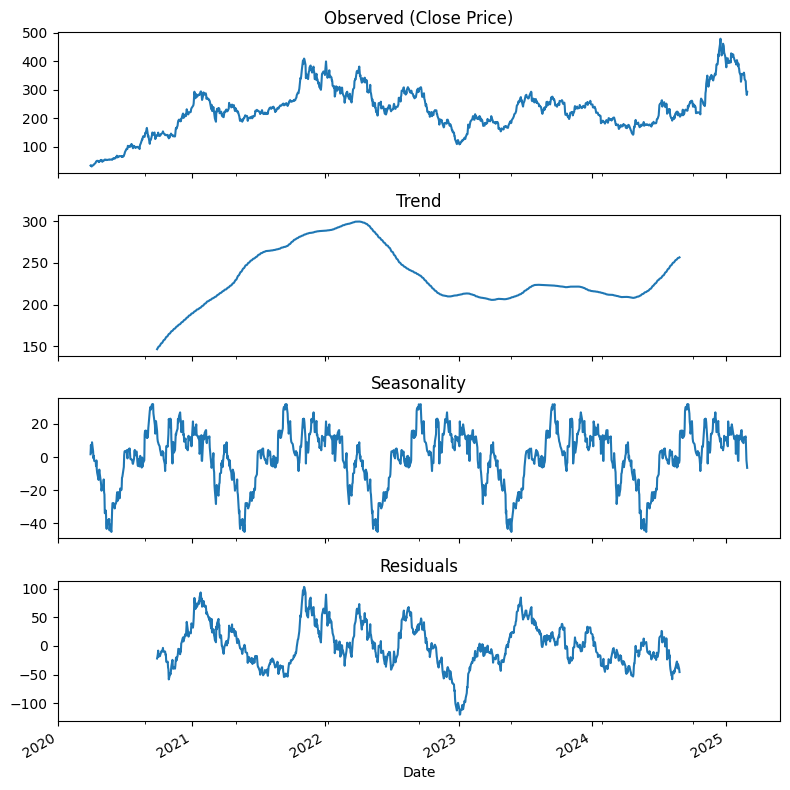

In [9]:
# Decompose Close prices
decompose_close = seasonal_decompose(tsla_data['Close'], model='additive', period=252)  # 252 trading days in a year

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
decompose_close.observed.plot(ax=axes[0], title='Observed (Close Price)')
decompose_close.trend.plot(ax=axes[1], title='Trend')
decompose_close.seasonal.plot(ax=axes[2], title='Seasonality')
decompose_close.resid.plot(ax=axes[3], title='Residuals')
plt.tight_layout()
plt.show()

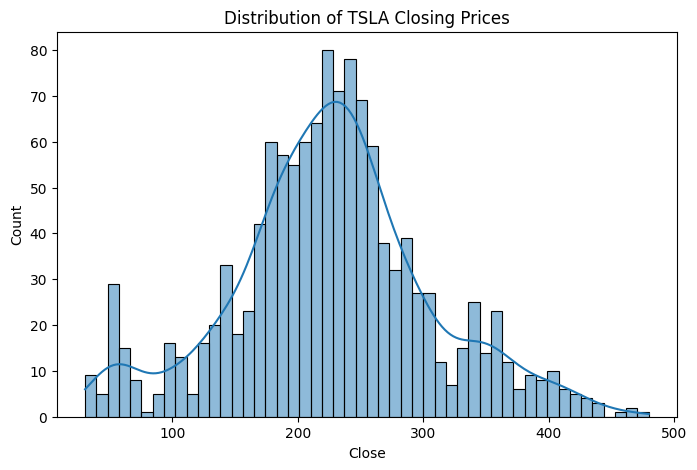

In [10]:
# Plot Distribution
plt.figure(figsize=(8, 5))
sns.histplot(tsla_data['Close'], bins=50, kde=True)
plt.title("Distribution of TSLA Closing Prices")
plt.show()


In [11]:

tsla_close = tsla_data['Close'].dropna()

# Shapiro-Wilk Test (for small sample sizes, n < 5000)
shapiro_stat, shapiro_p = shapiro(tsla_close)

# Kolmogorov-Smirnov Test (for larger datasets)
ks_stat, ks_p = kstest(tsla_close, 'norm', args=(tsla_close.mean(), tsla_close.std()))

# Print results
print(f"Shapiro-Wilk Test: Statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
print(f"Kolmogorov-Smirnov Test: Statistic={ks_stat:.4f}, p-value={ks_p:.4f}")

# Interpretation
if shapiro_p < 0.05:
    print("Shapiro-Wilk: The closing prices do NOT follow a normal distribution.")
else:
    print("Shapiro-Wilk: The closing prices may be normally distributed.")

if ks_p < 0.05:
    print("Kolmogorov-Smirnov: The closing prices do NOT follow a normal distribution.")
else:
    print("Kolmogorov-Smirnov: The closing prices may be normally distributed.")

Shapiro-Wilk Test: Statistic=0.9849, p-value=0.0000
Kolmogorov-Smirnov Test: Statistic=0.0584, p-value=0.0004
Shapiro-Wilk: The closing prices do NOT follow a normal distribution.
Kolmogorov-Smirnov: The closing prices do NOT follow a normal distribution.


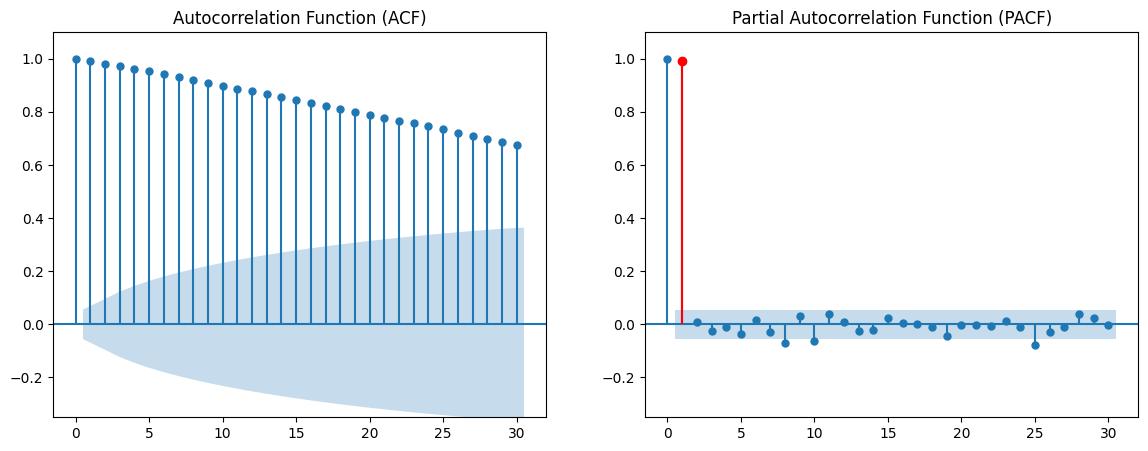

In [12]:
# ACF and PACF Plots with confidence intervalls
lags = 30
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(tsla_data['Close'], lags=30, ax=ax[0])
ax[0].set_title("Autocorrelation Function (ACF)")
ax[0].set_ylim(-0.35, 1.1)  # Shift the plot a bit down

plot_pacf(tsla_data['Close'], lags=30, ax=ax[1])
# Highlight the first PACF value which is important for our case
# These two lines just print on top of the plot_pacf()
pacf_values = pacf(tsla_data['Close'], nlags=lags)[1:2]
ax[1].stem(range(1, 2), pacf_values, linefmt='r-', markerfmt='ro', basefmt='k-')

ax[1].set_title("Partial Autocorrelation Function (PACF)")
ax[1].set_ylim(-0.35, 1.1)  # Shift the plot a bit down

plt.show()


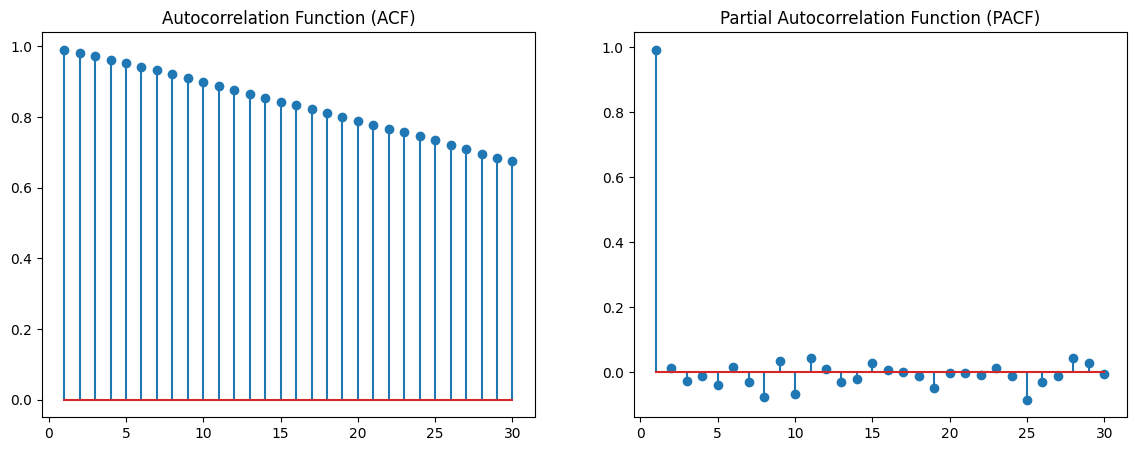

In [13]:
# Autocorrelation and Partial Autocorrelation
lags = 30
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].stem(range(1, lags+1), acf(tsla_data['Close'], nlags=lags)[1:])
ax[0].set_title("Autocorrelation Function (ACF)")

ax[1].stem(range(1, lags+1), pacf(tsla_data['Close'], nlags=lags)[1:])
ax[1].set_title("Partial Autocorrelation Function (PACF)")

plt.show()

In [14]:
# Stationarity Tests
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print("Time series is stationary (Reject H0)")
    else:
        print("Time series is non-stationary (Fail to reject H0)")

def kpss_test(series):
    result = kpss(series, regression='c', nlags="auto")
    print(f'KPSS Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}')
    if result[1] > 0.05:
        print("Time series is stationary (Fail to reject H0)")
    else:
        print("Time series is non-stationary (Reject H0)")

print("\nAugmented Dickey-Fuller (ADF) Test:")
adf_test(tsla_data['Close'])

print("\nKPSS Test:")
kpss_test(tsla_data['Close'])


Augmented Dickey-Fuller (ADF) Test:
ADF Statistic: -2.8381, p-value: 0.0530
Time series is non-stationary (Fail to reject H0)

KPSS Test:
KPSS Statistic: 1.0434, p-value: 0.0100
Time series is non-stationary (Reject H0)


In [15]:
df=pd.DataFrame(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1237 entries, 2020-03-30 00:00:00-04:00 to 2025-02-28 00:00:00-05:00
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1237 non-null   float64
 1   High          1237 non-null   float64
 2   Low           1237 non-null   float64
 3   Close         1237 non-null   float64
 4   Volume        1237 non-null   int64  
 5   Dividends     1237 non-null   float64
 6   Stock Splits  1237 non-null   float64
 7   Returns       1237 non-null   float64
 8   MA7           1237 non-null   float64
 9   MA21          1237 non-null   float64
 10  Volume_MA7    1237 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 116.0 KB


In [16]:
lags = 5
for i in range(1, lags + 1):
    df[f'Close_Lag_{i}'] = df['Close'].shift(i)
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns,MA7,MA21,Volume_MA7,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_4,Close_Lag_5
Date,,,,,,,,,,,,,,,,
2020-03-30 00:00:00-04:00,34.017334,34.443333,32.748669,33.475334,179971500,0.0,0.0,-0.023777,32.864001,37.384858,2.841731e+08,NaN,NaN,NaN,NaN,NaN
2020-03-31 00:00:00-04:00,33.416668,36.197334,33.133331,34.933334,266572500,0.0,0.0,0.043554,33.782763,36.687651,2.616431e+08,33.475334,NaN,NaN,NaN,NaN
2020-04-01 00:00:00-04:00,33.599998,34.263332,31.673332,32.104000,200298000,0.0,0.0,-0.080992,34.232953,35.849715,2.549974e+08,34.933334,33.475334,NaN,NaN,NaN
2020-04-02 00:00:00-04:00,32.068668,32.950668,29.760000,30.298000,297876000,0.0,0.0,-0.056255,33.751715,34.913111,2.484900e+08,32.104000,34.933334,33.475334,NaN,NaN
2020-04-03 00:00:00-04:00,33.966667,34.366001,31.226000,32.000668,338431500,0.0,0.0,0.056197,33.187525,34.136826,2.513601e+08,30.298000,32.104000,34.933334,33.475334,NaN


In [17]:
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns,MA7,MA21,Volume_MA7,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_4,Close_Lag_5
Date,,,,,,,,,,,,,,,,
2020-03-30 00:00:00-04:00,34.017334,34.443333,32.748669,33.475334,179971500,0.0,0.0,-0.023777,32.864001,37.384858,2.841731e+08,NaN,NaN,NaN,NaN,NaN
2020-03-31 00:00:00-04:00,33.416668,36.197334,33.133331,34.933334,266572500,0.0,0.0,0.043554,33.782763,36.687651,2.616431e+08,33.475334,NaN,NaN,NaN,NaN
2020-04-01 00:00:00-04:00,33.599998,34.263332,31.673332,32.104000,200298000,0.0,0.0,-0.080992,34.232953,35.849715,2.549974e+08,34.933334,33.475334,NaN,NaN,NaN
2020-04-02 00:00:00-04:00,32.068668,32.950668,29.760000,30.298000,297876000,0.0,0.0,-0.056255,33.751715,34.913111,2.484900e+08,32.104000,34.933334,33.475334,NaN,NaN
2020-04-03 00:00:00-04:00,33.966667,34.366001,31.226000,32.000668,338431500,0.0,0.0,0.056197,33.187525,34.136826,2.513601e+08,30.298000,32.104000,34.933334,33.475334,NaN


## Step2.1: Build MLP model on TSLA CLose

In [18]:


# Drop NaN values
df.dropna(inplace=True)
df1=df.copy()
# Prepare features
features = ['Returns', 'MA7', 'MA21', 'Volume', 'Volume_MA7','Close_Lag_1',
            'Close_Lag_2','Close_Lag_3','Close_Lag_4','Close_Lag_5']
target = 'Close'

# Scale the features
scaler = MinMaxScaler()
#scaler_y = MinMaxScaler()

# Scale features and target separately
X_scaled1 = scaler.fit_transform(df1[features])
y_scaled1 = scaler.fit_transform(df1[[target]])

In [19]:
X_scaled1.shape

(1232, 10)

In [20]:
# Split dataset
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_scaled1, y_scaled1, test_size=0.2, shuffle=False)

# Build MLP Model
model1 = keras.Sequential([
    keras.layers.Dense(64, activation='tanh', input_shape=(X_train1.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='tanh'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1,activation='linear')  # Output layer
])

model1.compile(optimizer='adam', loss='mse')
# Add early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
# Train Model
history1=model1.fit(X_train1, y_train1, epochs=50, batch_size=16, validation_split=0.1,
          validation_data=(X_test1, y_test1),
          callbacks=[early_stopping],
          verbose=1)



Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1117 - val_loss: 0.0069
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0264 - val_loss: 0.0034
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130 - val_loss: 0.0033
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0101 - val_loss: 0.0014
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0082 - val_loss: 0.0020
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0073 - val_loss: 0.0012
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0059 - val_loss: 0.0010
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0059 - val_loss: 0.0016
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0042 - val_loss: 0.0015
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0041 - val_loss: 9.1260e-04
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0045 - val_loss: 0.0016
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039 - v

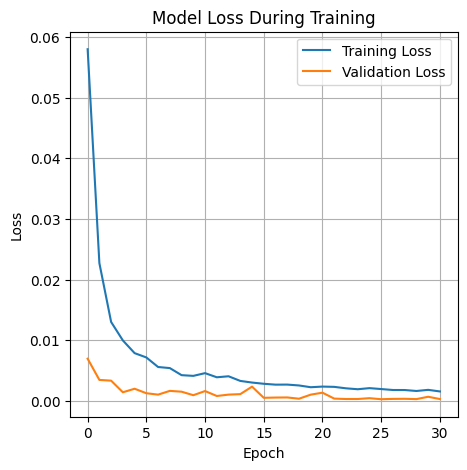

In [21]:
# Plot training history
plt.figure(figsize=(5, 5))
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Predict
predictions1 = model1.predict(X_test1)

# Inverse Transform Predictions
predicted_prices1 = scaler.inverse_transform(predictions1)

# Save Model
model1.save("mlp_tsla_forecast1.h5")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [23]:
# Evaluate Performance
mse1 = mean_squared_error(y_test1, predictions1)
r21 = r2_score(y_test1, predictions1)

print(f"MLP Performance on Non-Stationary Series:")
print(f"MSE: {mse1:.5f}")
print(f"R² Score: {r21:.5f}")


MLP Performance on Non-Stationary Series:
MSE: 0.00025
R² Score: 0.99357


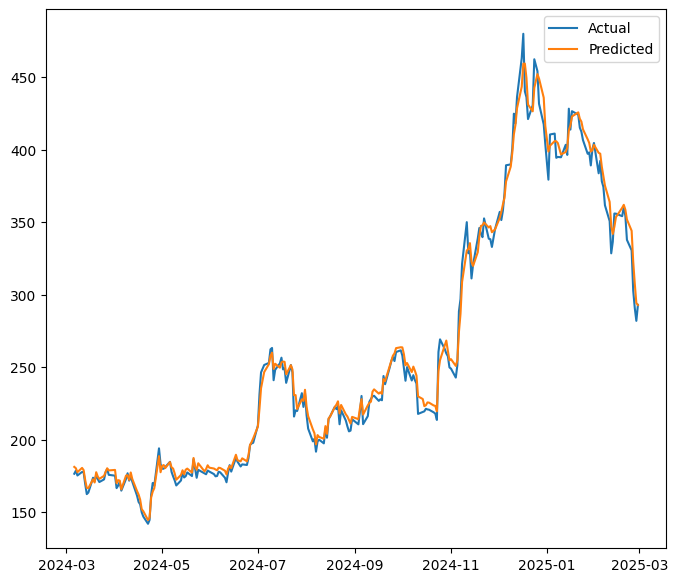

In [24]:
# Display results

plt.figure(figsize=(8,7))
plt.plot(df.index[-len(y_test1):], scaler.inverse_transform(y_test1.reshape(-1,1)), label="Actual")
plt.plot(df.index[-len(y_test1):], predicted_prices1, label="Predicted")
plt.legend()
plt.show()

## Step 1.2: TESLA Stationary Time Series: Summary Statistics
## TSLA['Close_Diff']

In [25]:
df2=df.copy()
# Transform Data: First Differences to Remove Trend
df2['Close_Diff'] = df2['Close'].diff()

# Drop NaN values due to differencing
df2.dropna(inplace=True)

# Summary Statistics for Differenced Series
print("Summary Statistics for Stationary (Differenced) Series:")
print(df2['Close_Diff'].describe())

# Skewness and Kurtosis
print(f"Skewness: {df2['Close_Diff'].skew():.2f}")
print(f"Kurtosis: {df2['Close_Diff'].kurtosis():.2f}")



Summary Statistics for Stationary (Differenced) Series:
count    1231.000000
mean        0.210044
std         9.235333
min       -46.480011
25%        -4.008339
50%         0.339996
75%         4.743340
max        47.666656
Name: Close_Diff, dtype: float64
Skewness: 0.05
Kurtosis: 3.32


In [26]:
# Define Features & Target
features = ['Returns', 'MA7', 'MA21', 'Volume', 'Volume_MA7',
            'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5']

 # Apply fractional differencing and create new columns
for col in features:
    df2[col + '_Diff'] = df2[col].diff().values
    df2.drop(columns=[col], inplace=True)  # Drop the original column
df2.dropna(inplace=True)
# Display the updated DataFrame
print(df2.head())

                                Open       High        Low      Close  \
Date                                                                    
2020-04-08 00:00:00-04:00  36.946667  37.147331  35.555332  36.589333   
2020-04-09 00:00:00-04:00  37.472668  38.345333  37.140667  38.200001   
2020-04-13 00:00:00-04:00  39.344002  43.466667  38.702000  43.396667   
2020-04-14 00:00:00-04:00  46.598000  49.458668  46.161999  47.326000   
2020-04-15 00:00:00-04:00  49.466667  50.208668  47.333332  48.655334   

                           Dividends  Stock Splits  Close_Diff  Returns_Diff  \
Date                                                                           
2020-04-08 00:00:00-04:00        0.0           0.0    0.225998     -0.050367   
2020-04-09 00:00:00-04:00        0.0           0.0    1.610668      0.037805   
2020-04-13 00:00:00-04:00        0.0           0.0    5.196667      0.092018   
2020-04-14 00:00:00-04:00        0.0           0.0    3.929333     -0.045494   
2020-04-

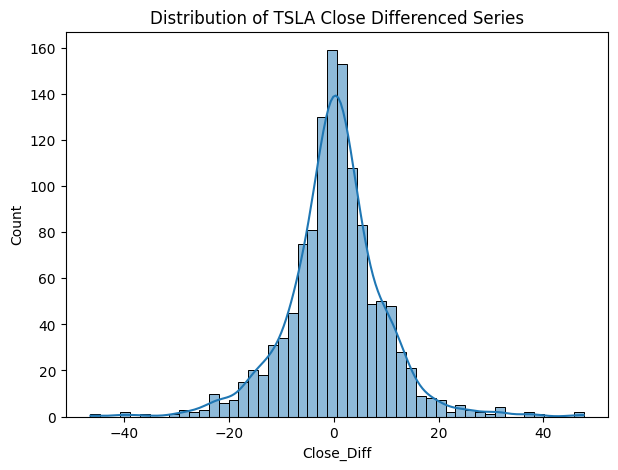

In [27]:
# Plot Distribution
plt.figure(figsize=(7, 5))
sns.histplot(df2['Close_Diff'], bins=50, kde=True)
plt.title("Distribution of TSLA Close Differenced Series")
plt.show()

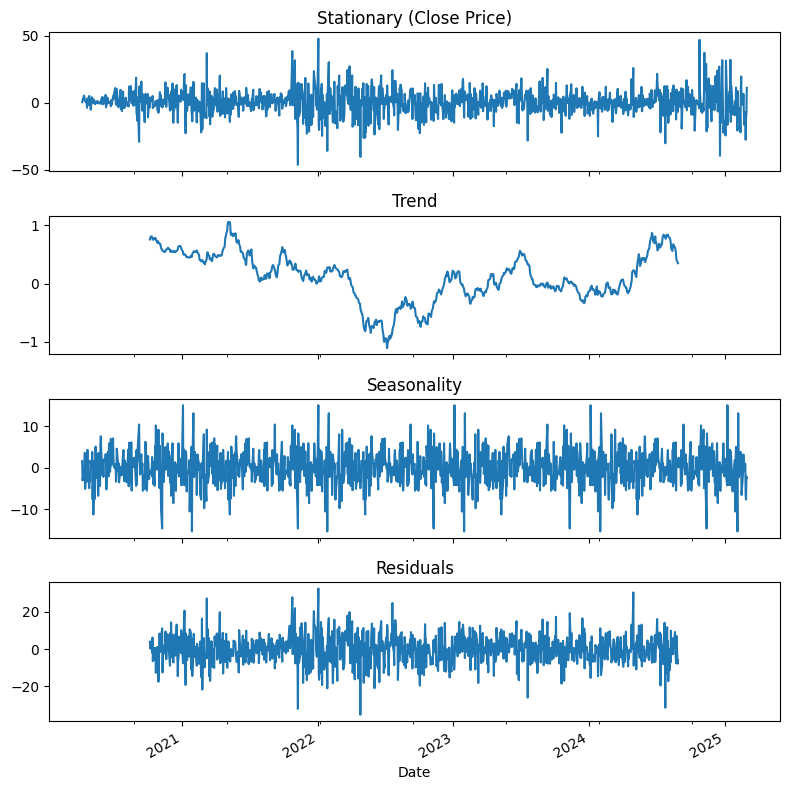

In [28]:
# Decompose Close prices
decompose_closediff = seasonal_decompose(df2['Close_Diff'], model='additive', period=252)  # 252 trading days in a year

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
decompose_closediff.observed.plot(ax=axes[0], title='Stationary (Close Price)')
decompose_closediff.trend.plot(ax=axes[1], title='Trend')
decompose_closediff.seasonal.plot(ax=axes[2], title='Seasonality')
decompose_closediff.resid.plot(ax=axes[3], title='Residuals')
plt.tight_layout()
plt.show()

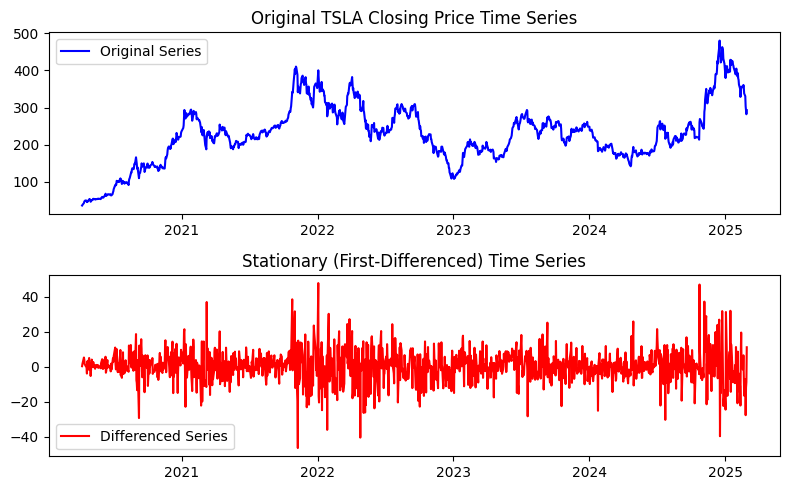

In [29]:
# Plot Original vs. Differenced Series
plt.figure(figsize=(8, 5))
plt.subplot(2, 1, 1)
plt.plot(df2['Close'], label="Original Series", color='blue')
plt.title("Original TSLA Closing Price Time Series")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df2['Close_Diff'], label="Differenced Series", color='red')
plt.title("Stationary (First-Differenced) Time Series")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
tsla_close2 = df2['Close_Diff'].dropna()

# Shapiro-Wilk Test (for small sample sizes, n < 5000)
shapiro_stat2, shapiro_p2 = shapiro(tsla_close2)

# Kolmogorov-Smirnov Test (for larger datasets)
ks_stat2, ks_p2 = kstest(tsla_close2, 'norm', args=(tsla_close2.mean(), tsla_close2.std()))

# Print results
print(f"Shapiro-Wilk Test: Statistic={shapiro_stat2:.4f}, p-value={shapiro_p2:.4f}")
print(f"Kolmogorov-Smirnov Test: Statistic={ks_stat2:.4f}, p-value={ks_p2:.4f}")

# Interpretation
if shapiro_p2 < 0.05:
    print("Shapiro-Wilk: The Differenced closing prices do NOT follow a normal distribution.")
else:
    print("Shapiro-Wilk: The differenced closing prices may be normally distributed.")

if ks_p2 < 0.05:
    print("Kolmogorov-Smirnov: The differenced closing prices do NOT follow a normal distribution.")
else:
    print("Kolmogorov-Smirnov: The differenced closing prices may be normally distributed.")

Shapiro-Wilk Test: Statistic=0.9569, p-value=0.0000
Kolmogorov-Smirnov Test: Statistic=0.0765, p-value=0.0000
Shapiro-Wilk: The Differenced closing prices do NOT follow a normal distribution.
Kolmogorov-Smirnov: The differenced closing prices do NOT follow a normal distribution.


In [31]:
# Augmented Dickey-Fuller (ADF) Test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print("Time series is stationary (Reject H0)")
    else:
        print("Time series is non-stationary (Fail to reject H0)")

# KPSS Test
def kpss_test(series):
    result = kpss(series, regression='c', nlags="auto")
    print(f'KPSS Statistic: {result[0]:.4f}, p-value: {result[1]:.4f}')
    if result[1] > 0.05:
        print("Time series is stationary (Fail to reject H0)")
    else:
        print("Time series is non-stationary (Reject H0)")

print("\nAugmented Dickey-Fuller (ADF) Test for Differenced Series:")
adf_test(df2['Close_Diff'])

print("\nKPSS Test for Differenced Series:")
kpss_test(df2['Close_Diff'])


Augmented Dickey-Fuller (ADF) Test for Differenced Series:
ADF Statistic: -10.1890, p-value: 0.0000
Time series is stationary (Reject H0)

KPSS Test for Differenced Series:
KPSS Statistic: 0.1067, p-value: 0.1000
Time series is stationary (Fail to reject H0)


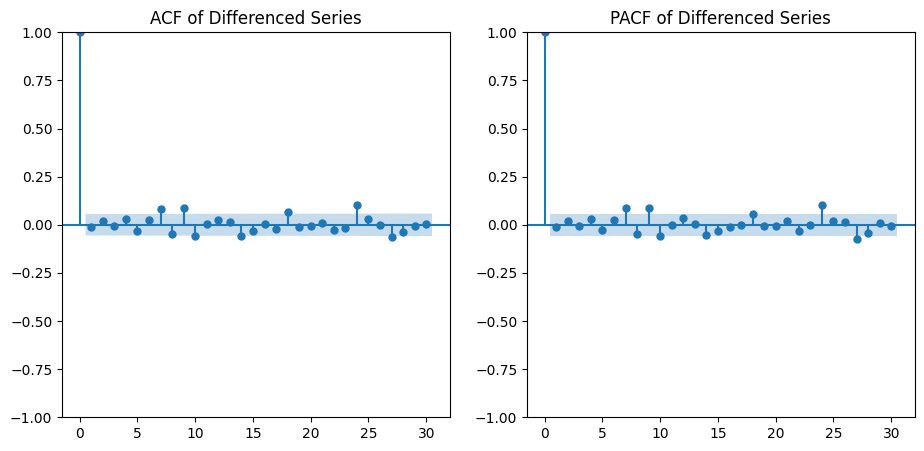

In [32]:
# ACF and PACF Plots for Differenced Series
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

plot_acf(df2['Close_Diff'], lags=30, ax=ax[0])
ax[0].set_title("ACF of Differenced Series")

plot_pacf(df2['Close_Diff'], lags=30, ax=ax[1])
ax[1].set_title("PACF of Differenced Series")

plt.show()

In [33]:
# Define Features & Target
features = ['Returns_Diff', 'MA7_Diff', 'MA21_Diff', 'Volume_Diff', 'Volume_MA7_Diff',
            'Close_Lag_1_Diff', 'Close_Lag_2_Diff', 'Close_Lag_3_Diff', 'Close_Lag_4_Diff',
            'Close_Lag_5_Diff']
target = 'Close_Diff'  # Predicting the stationary version

X2 = df2[features]
y2 = df2[target]

# Train-Test Split (80-20)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, shuffle=False,random_state=42)


In [34]:
len(y_test2)

246

In [35]:
len(y_train2)

984

In [36]:
# Scale Features
scaler = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled2 = scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)
y_train_scaled2 = scaler_y.fit_transform(pd.DataFrame(y_train2))
y_test_scaled2 = scaler_y.fit_transform(pd.DataFrame(y_test2))
## MLP Model with Early Stopping for Loss Tracking
#mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
#                   max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.2)

#mlp.fit(X_train_scaled2, y_train_scaled2)
# Build MLP Model
model2 = keras.Sequential([
    keras.layers.Dense(64, activation='tanh', input_shape=(X_train_scaled2.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='tanh'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1,activation='linear')  # Output layer
])

model2.compile(optimizer='adam', loss='mse')
# Add early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
# Train Model
history2=model2.fit(X_train_scaled2, y_train_scaled2, epochs=50, batch_size=16, validation_split=0.2,
          validation_data=(X_test_scaled2, y_test_scaled2),
          callbacks=[early_stopping],
          verbose=1)




Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8550 - val_loss: 0.2984
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4065 - val_loss: 0.2228
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3439 - val_loss: 0.2274
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3057 - val_loss: 0.2063
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3572 - val_loss: 0.2020
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2851 - val_loss: 0.2000
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3244 - val_loss: 0.2095
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2665 - val_loss: 0.1993
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2466 - val_loss: 0.1995
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2582 - val_loss: 0.1967
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2385 - val_loss: 0.1888
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2242 - val_lo

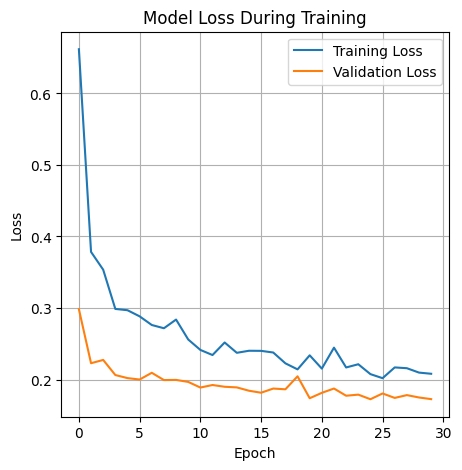

In [37]:
# Plot training history
plt.figure(figsize=(5, 5))
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# Predictions
y_pred2 = model2.predict(X_test_scaled2)

# Evaluate Model
mse = mean_squared_error(y_test_scaled2, y_pred2)
r2 = r2_score(y_test_scaled2, y_pred2)

print(f"MLP Model Performance:\nMSE: {mse:.5f}, R² Score: {r2:.5f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
MLP Model Performance:
MSE: 0.17249, R² Score: 0.82751


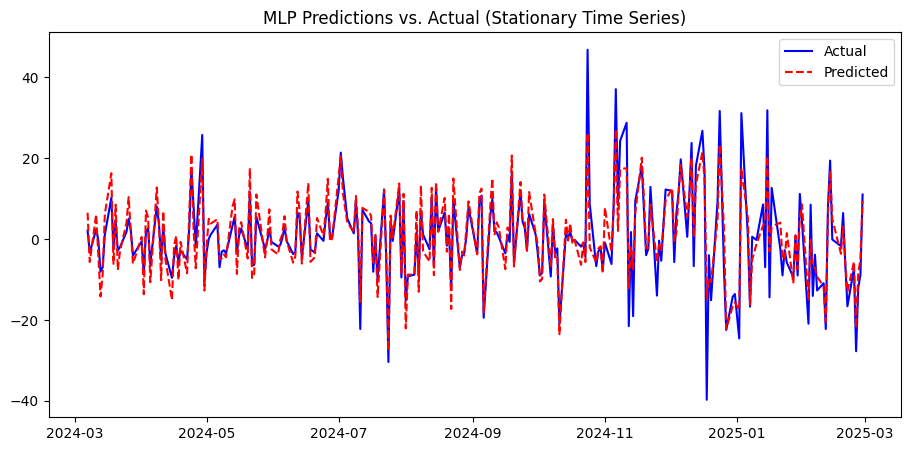

In [39]:
#y_test_scaled2_inv=scaler_y.inverse_transform(y_test_scaled2)
y_pred2_inv=scaler_y.inverse_transform(y_pred2.reshape(-1, 1))
# Plot Predictions vs Actual
plt.figure(figsize=(11, 5))
plt.plot(y_test2.index,y_test2 , label="Actual", color='blue')
plt.plot(y_test2.index, y_pred2_inv, label="Predicted", color='red', linestyle='dashed')
plt.title("MLP Predictions vs. Actual (Stationary Time Series)")
plt.legend()
plt.show()

In [40]:
len(y_pred2_inv)

246

In [41]:
len(y_test2)

246

In [42]:
index2=int(len(y2)*0.8)

index2

984

In [43]:
len(df2)

1230

In [44]:
# Reconstruct Close prices
df22=df2.iloc[index2:].copy()
len(df22)

246

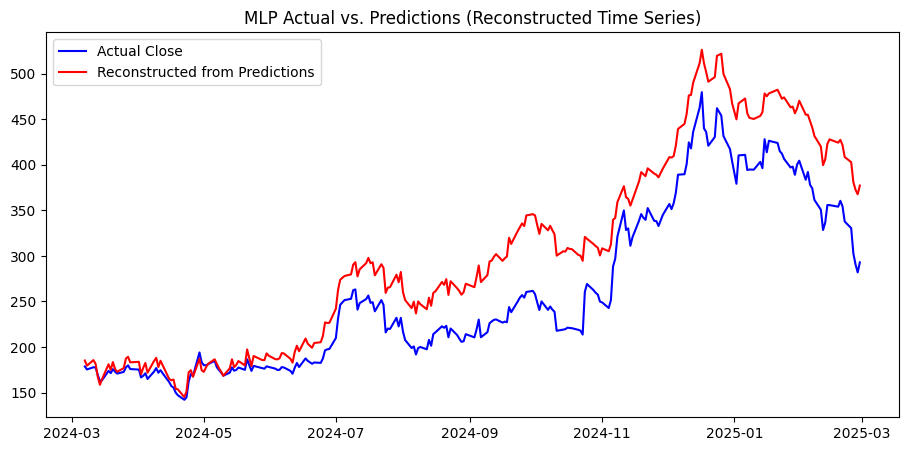

In [45]:

#index=np.where(y_test2==df2['Close_Diff'])
df22['Close_Reconstructed'] = df22['Close'].iloc[0] + y_pred2_inv.cumsum()
# Plot Predictions vs Actual
plt.figure(figsize=(11, 5))
plt.plot(y_test2.index, df22['Close'], label="Actual Close", color='blue')
plt.plot(y_test2.index, df22['Close_Reconstructed'], label="Reconstructed from Predictions", color='red')
plt.title("MLP Actual vs. Predictions (Reconstructed Time Series)")
plt.legend()
plt.show()


## 1.3: Fractionally differenced time series

In [46]:
df3=df.copy()
def get_weights(d, n):
    """Compute fractional differencing weights using binomial expansion."""
    weights = [1]
    for k in range(1, n):
        weight = -weights[-1] * ((d - k + 1) / k)
        weights.append(weight)
    return np.array(weights[::-1])  # Reverse order for convolution

def fractional_diff(series, d, thresh=1e-5):
    """Apply fractional differencing to a time series."""
    weights = get_weights(d, 100)  # Use 100 lags
    weights = weights[np.abs(weights) > thresh]  # Drop small weights

    diff_series = np.convolve(series, weights, mode='valid')  # Convolution
    return np.concatenate((np.full(len(series) - len(diff_series), np.nan), diff_series))


In [47]:
df3['Close_FD'] = fractional_diff(df3['Close'].dropna(), d=0.4)

In [48]:
# Define Features & Target
features = ['Returns', 'MA7', 'MA21', 'Volume', 'Volume_MA7',
            'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5']

 # Apply fractional differencing and create new columns
for col in features:
    df3[col + '_FD'] = fractional_diff(df3[col].dropna().values, d=0.4)
    df3.drop(columns=[col], inplace=True)  # Drop the original column

# Display the updated DataFrame
print(df3.head())

                                Open       High        Low      Close  \
Date                                                                    
2020-04-06 00:00:00-04:00  34.080002  34.733334  33.197334  34.416000   
2020-04-07 00:00:00-04:00  36.333332  37.666668  35.489334  36.363335   
2020-04-08 00:00:00-04:00  36.946667  37.147331  35.555332  36.589333   
2020-04-09 00:00:00-04:00  37.472668  38.345333  37.140667  38.200001   
2020-04-13 00:00:00-04:00  39.344002  43.466667  38.702000  43.396667   

                           Dividends  Stock Splits  Close_FD  Returns_FD  \
Date                                                                       
2020-04-06 00:00:00-04:00        0.0           0.0       NaN         NaN   
2020-04-07 00:00:00-04:00        0.0           0.0       NaN         NaN   
2020-04-08 00:00:00-04:00        0.0           0.0       NaN         NaN   
2020-04-09 00:00:00-04:00        0.0           0.0       NaN         NaN   
2020-04-13 00:00:00-04:00       

In [49]:
df3.dropna(inplace=True)
df3.head()

,Open,High,Low,Close,Dividends,Stock Splits,Close_FD,Returns_FD,MA7_FD,MA21_FD,Volume_FD,Volume_MA7_FD,Close_Lag_1_FD,Close_Lag_2_FD,Close_Lag_3_FD,Close_Lag_4_FD,Close_Lag_5_FD
Date,,,,,,,,,,,,,,,,,
2020-08-26 00:00:00-04:00,137.333328,144.399994,136.908661,143.544662,0.0,0.0,-3.812908,0.038601,-2.129432,0.249519,-6.247193e+06,1.790529e+07,-4.856179,-4.917517,-1.661379,1.183959,-1.098109
2020-08-27 00:00:00-04:00,145.363998,153.039993,142.833328,149.250000,0.0,0.0,-2.792494,0.033681,-2.564947,-0.063740,6.077823e+07,2.406160e+07,-3.812908,-4.856179,-4.917517,-1.661379,1.183959
2020-08-28 00:00:00-04:00,153.007996,154.565994,145.768005,147.559998,0.0,0.0,-4.256414,-0.036680,-3.016133,-0.618999,-4.040164e+07,2.543999e+07,-2.792494,-3.812908,-4.856179,-4.917517,-1.661379
2020-08-31 00:00:00-04:00,148.203339,166.713333,146.703339,166.106674,0.0,5.0,-5.417256,-0.025391,-3.959164,-1.309669,-8.221511e+07,6.216988e+06,-4.256414,-2.792494,-3.812908,-4.856179,-4.917517
2020-09-01 00:00:00-04:00,167.380005,167.496674,156.836670,158.350006,0.0,0.0,-2.108098,0.093638,-4.022981,-1.662278,2.025216e+07,1.655195e+07,-5.417256,-4.256414,-2.792494,-3.812908,-4.856179


In [50]:
# Summary Statistics for Differenced Series
print("Summary Statistics for Fractionally  (Differenced) Series:")
print(df3['Close_FD'].describe())

# Skewness and Kurtosis
print(f"Skewness: {df3['Close_FD'].skew():.2f}")
print(f"Kurtosis: {df3['Close_FD'].kurtosis():.2f}")


Summary Statistics for Fractionally  (Differenced) Series:
count    1133.000000
mean       21.774526
std        16.151691
min       -16.302437
25%         9.984293
50%        20.304346
75%        32.354179
max        80.902226
Name: Close_FD, dtype: float64
Skewness: 0.54
Kurtosis: 0.25


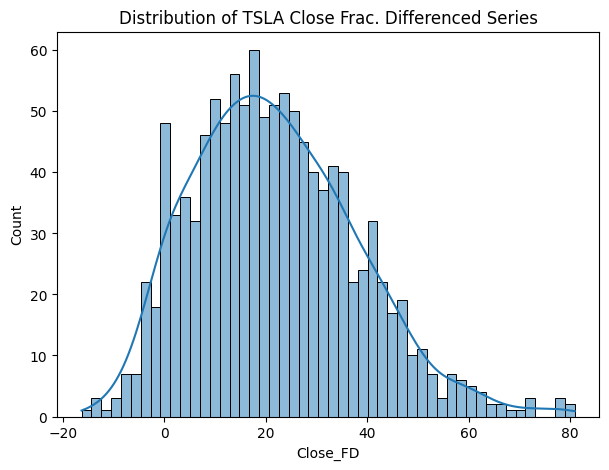

In [51]:
# Plot Distribution
plt.figure(figsize=(7, 5))
sns.histplot(df3['Close_FD'], bins=50, kde=True)
plt.title("Distribution of TSLA Close Frac. Differenced Series")
plt.show()

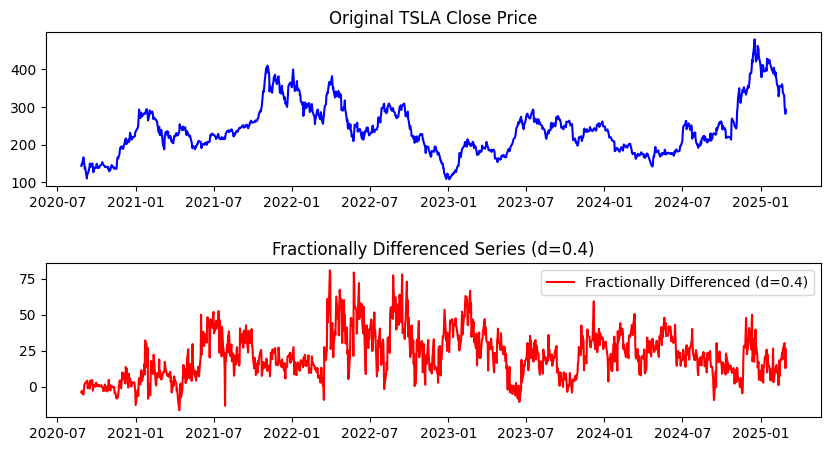

In [52]:
# Drop NaN values from differencing
df3.dropna(inplace=True)
d=0.4
# --- 1. Plot Original vs. Fractionally Differenced Series ---
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(df3['Close'], label='Original Close Price', color='blue')
plt.title("Original TSLA Close Price")

plt.subplot(2, 1, 2)
plt.plot(df3['Close_FD'], label=f'Fractionally Differenced (d={d})', color='red')
plt.title(f"Fractionally Differenced Series (d={d})")
plt.legend()
plt.subplots_adjust(hspace=0.5)
plt.show()

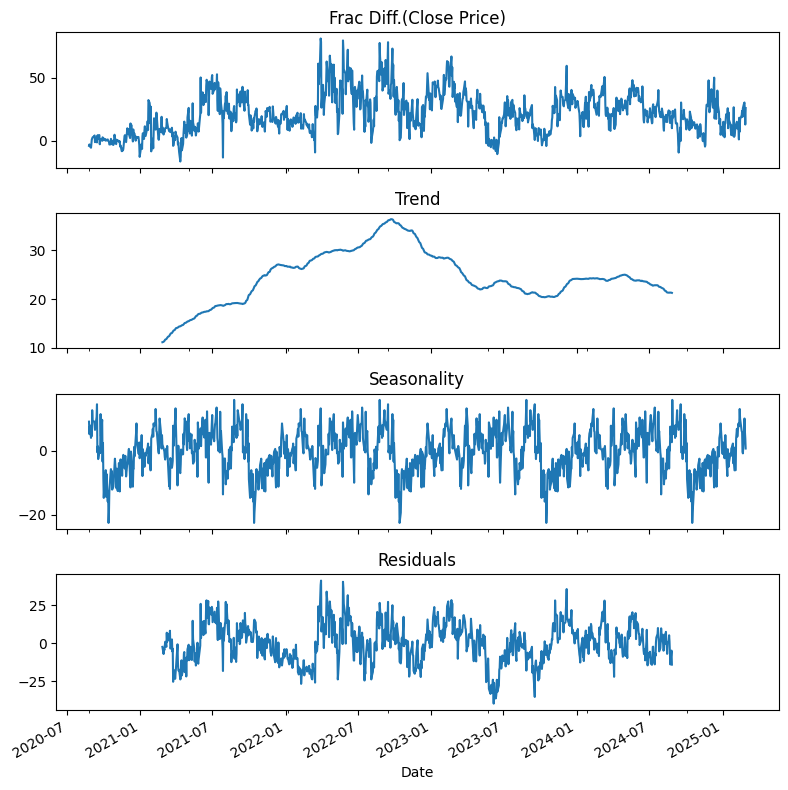

In [53]:
# Decompose Close prices
decompose_fracclosediff = seasonal_decompose(df3['Close_FD'], model='additive', period=252)  # 252 trading days in a year

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
decompose_fracclosediff.observed.plot(ax=axes[0], title='Frac Diff.(Close Price)')
decompose_fracclosediff.trend.plot(ax=axes[1], title='Trend')
decompose_fracclosediff.seasonal.plot(ax=axes[2], title='Seasonality')
decompose_fracclosediff.resid.plot(ax=axes[3], title='Residuals')
plt.tight_layout()
plt.show()

In [54]:
tsla_close3 = df3['Close_FD'].dropna()

# Shapiro-Wilk Test (for small sample sizes, n < 5000)
shapiro_stat3, shapiro_p3 = shapiro(tsla_close3)

# Kolmogorov-Smirnov Test (for larger datasets)
ks_stat3, ks_p3 = kstest(tsla_close3, 'norm', args=(tsla_close3.mean(), tsla_close3.std()))

# Print results
print(f"Shapiro-Wilk Test: Statistic={shapiro_stat3:.4f}, p-value={shapiro_p3:.4f}")
print(f"Kolmogorov-Smirnov Test: Statistic={ks_stat3:.4f}, p-value={ks_p3:.4f}")

# Interpretation
if shapiro_p3 < 0.05:
    print("Shapiro-Wilk: The Differenced closing prices do NOT follow a normal distribution.")
else:
    print("Shapiro-Wilk: The differenced closing prices may be normally distributed.")

if ks_p3 < 0.05:
    print("Kolmogorov-Smirnov: The differenced closing prices do NOT follow a normal distribution.")
else:
    print("Kolmogorov-Smirnov: The differenced closing prices may be normally distributed.")

Shapiro-Wilk Test: Statistic=0.9809, p-value=0.0000
Kolmogorov-Smirnov Test: Statistic=0.0430, p-value=0.0294
Shapiro-Wilk: The Differenced closing prices do NOT follow a normal distribution.
Kolmogorov-Smirnov: The differenced closing prices do NOT follow a normal distribution.


In [55]:
# --- 2. Augmented Dickey-Fuller (ADF) Test ---
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print("ADF Test Results:")
    print(f"ADF Statistic: {result[0]:.5f}")
    print(f"p-value: {result[1]:.5f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value:.5f}")
    print("Stationary" if result[1] < 0.05 else "Non-Stationary")

#print("Original Close Price ADF Test:")
#adf_test(df2Close'])
print("\nFractionally Differenced ADF Test:")
adf_test(df3['Close_FD'])




Fractionally Differenced ADF Test:
ADF Test Results:
ADF Statistic: -4.90527
p-value: 0.00003
Critical Values:
1%: -3.43619
5%: -2.86412
10%: -2.56814
Stationary


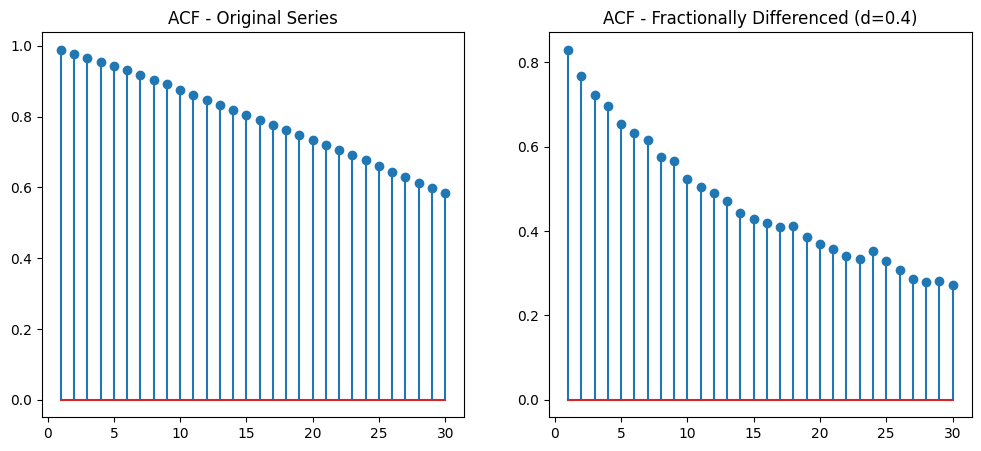

In [56]:
# --- 4. Plot ACF and PACF ---
lags = 30
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].stem(range(1, lags+1), acf(df3['Close'], nlags=lags)[1:])
ax[0].set_title("ACF - Original Series")

ax[1].stem(range(1, lags+1), acf(df3['Close_FD'], nlags=lags)[1:])
ax[1].set_title(f"ACF - Fractionally Differenced (d={d})")

plt.show()

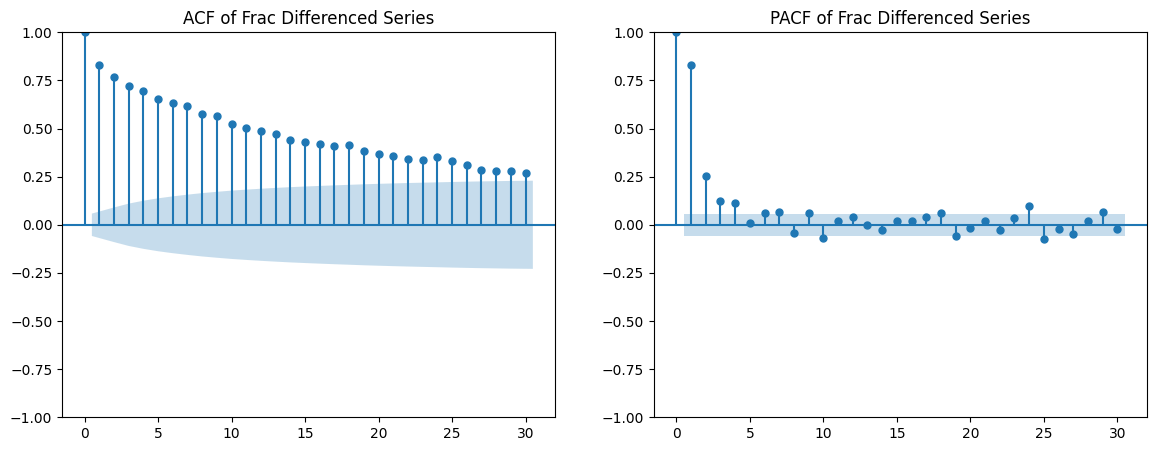

In [57]:
# ACF and PACF Plots for Differenced Series
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df3['Close_FD'], lags=30, ax=ax[0])
ax[0].set_title("ACF of Frac Differenced Series")

plot_pacf(df3['Close_FD'], lags=30, ax=ax[1])
ax[1].set_title("PACF of Frac Differenced Series")

plt.show()

In [58]:
df3.head(5)

,Open,High,Low,Close,Dividends,Stock Splits,Close_FD,Returns_FD,MA7_FD,MA21_FD,Volume_FD,Volume_MA7_FD,Close_Lag_1_FD,Close_Lag_2_FD,Close_Lag_3_FD,Close_Lag_4_FD,Close_Lag_5_FD
Date,,,,,,,,,,,,,,,,,
2020-08-26 00:00:00-04:00,137.333328,144.399994,136.908661,143.544662,0.0,0.0,-3.812908,0.038601,-2.129432,0.249519,-6.247193e+06,1.790529e+07,-4.856179,-4.917517,-1.661379,1.183959,-1.098109
2020-08-27 00:00:00-04:00,145.363998,153.039993,142.833328,149.250000,0.0,0.0,-2.792494,0.033681,-2.564947,-0.063740,6.077823e+07,2.406160e+07,-3.812908,-4.856179,-4.917517,-1.661379,1.183959
2020-08-28 00:00:00-04:00,153.007996,154.565994,145.768005,147.559998,0.0,0.0,-4.256414,-0.036680,-3.016133,-0.618999,-4.040164e+07,2.543999e+07,-2.792494,-3.812908,-4.856179,-4.917517,-1.661379
2020-08-31 00:00:00-04:00,148.203339,166.713333,146.703339,166.106674,0.0,5.0,-5.417256,-0.025391,-3.959164,-1.309669,-8.221511e+07,6.216988e+06,-4.256414,-2.792494,-3.812908,-4.856179,-4.917517
2020-09-01 00:00:00-04:00,167.380005,167.496674,156.836670,158.350006,0.0,0.0,-2.108098,0.093638,-4.022981,-1.662278,2.025216e+07,1.655195e+07,-5.417256,-4.256414,-2.792494,-3.812908,-4.856179


In [59]:
target3 = ['Close_FD']
features3 = ['Returns_FD', 'MA7_FD', 'MA21_FD', 'Volume_FD', 'Volume_MA7_FD',
            'Close_Lag_1_FD', 'Close_Lag_2_FD', 'Close_Lag_3_FD', 'Close_Lag_4_FD', 'Close_Lag_5_FD']
# Split Data
X3 = df3[features3]
y3 = df3[target3]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, shuffle=False)

In [60]:
#Scale Features
scaler_X3 = StandardScaler()
scaler_y3 = StandardScaler()

X_train_scaled3 = scaler_X3.fit_transform(X_train3)
X_test_scaled3 = scaler_X3.transform(X_test3)
y_train_scaled3 = scaler_y3.fit_transform(y_train3.values.reshape(-1, 1))
y_test_scaled3 = scaler_y3.transform(y_test3.values.reshape(-1, 1))

In [61]:
# Build MLP Model
model3 = keras.Sequential([
    keras.layers.Dense(64, activation='tanh', input_shape=(X_train3.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='tanh'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1,activation='linear')  # Output layer
])

model3.compile(optimizer='adam', loss='mse')
# Add early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
# Train Model
history3=model3.fit(X_train_scaled3, y_train_scaled3, epochs=50, batch_size=16, validation_split=0.1,
          validation_data=(X_test_scaled3, y_test_scaled3),
          callbacks=[early_stopping],
          verbose=1)



Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4938 - val_loss: 0.0440
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1937 - val_loss: 0.0160
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1540 - val_loss: 0.0121
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1117 - val_loss: 0.0277
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1027 - val_loss: 0.0078
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1042 - val_loss: 0.0090
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0872 - val_loss: 0.0078
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1026 - val_loss: 0.0062
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1003 - val_loss: 0.0096
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0775 - val_loss: 0.0071
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0908 - val_loss: 0.0063
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0757 - val_lo

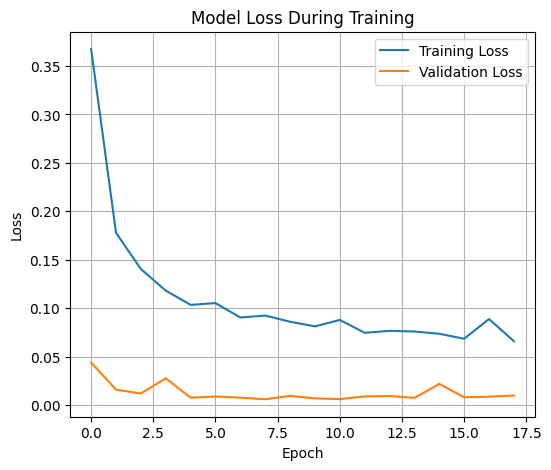

In [62]:
# Plot training history
plt.figure(figsize=(6, 5))
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [63]:
# Predict and Evaluate Model
y_pred_scaled3 = model3.predict(X_test_scaled3)
y_pred33 = scaler_y3.inverse_transform(y_pred_scaled3)

# Compute MSE & R-squared
mse3 = mean_squared_error(y_test3, y_pred33)
r23 = r2_score(y_test3, y_pred33)

print(f"Test MSE: {mse3:.5f}")
print(f"Test R-Squared: {r23:.5f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Test MSE: 1.81931
Test R-Squared: 0.98536


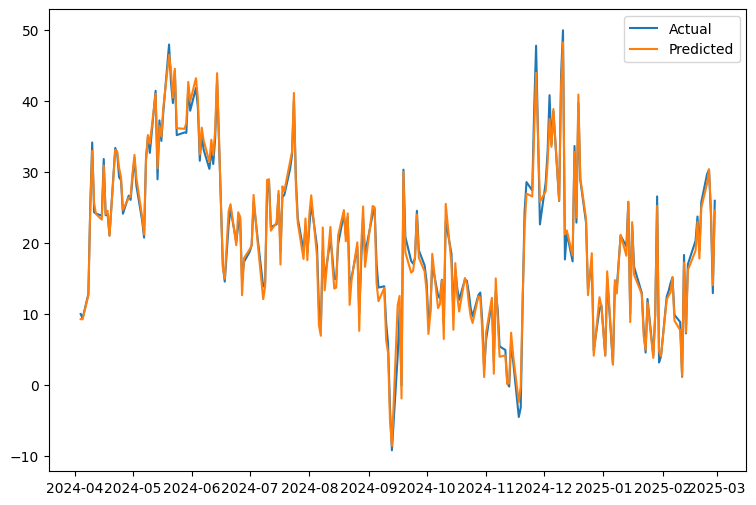

In [64]:
# Save Model
model3.save("mlp_tsla_forecast3.h5")

# Display results
plt.figure(figsize=(9,6))
plt.plot(df3.index[-len(y_test3):], y_test3, label="Actual")
plt.plot(df3.index[-len(y_test3):], y_pred33 , label="Predicted")
plt.legend()
plt.show()

In [65]:
# Function to compute fractional differencing weights (as used before)
def get_weights2(d, n):
    """Compute fractional differencing weights using binomial expansion."""
    weights = [1]
    for k in range(1, n):
        weight = -weights[-1] * ((d - k + 1) / k)
        weights.append(weight)
    return np.array(weights[::-1])  # Reverse order for convolution

# Function to reconstruct the original price series
def reconstruct_series2(fd_series, original_first_value, d, n_lags=100):
    """
    Reconstructs the original price series from a fractionally differenced series.

    Parameters:
    - fd_series: Fractionally differenced series (numpy array or pd.Series)
    - original_first_value: The first known price before differencing
    - d: Differencing parameter used (e.g., 0.4)
    - n_lags: Number of terms used for the inverse reconstruction

    Returns:
    - Reconstructed price series
    """
    # Compute weights
    # weights = get_weights2(d, n_lags)
    # weights = weights[::-1]  # Reverse weights for reconstruction

    # # Initialize reconstructed series
    # reconstructed_series = np.zeros(len(fd_series))
    # reconstructed_series[0] = original_first_value  # Start from first known value

    # # Iteratively reconstruct price
    # for i in range(1, len(fd_series)):
    #     reconstructed_series[i] = sum(weights[:i] * fd_series[:i][::-1]) + original_first_value
    weights = get_weights(d, n_lags)  # Get differencing weights
    reconstructed_series = np.zeros(len(fd_series) + 1)  # +1 for the first value
    reconstructed_series[0] = original_first_value  # Set the first value

    for i in range(1, len(reconstructed_series)):
        num_weights = min(i, len(weights))  # Limit the number of weights used
        reconstructed_series[i] = (
            sum(weights[:num_weights] * fd_series[max(0, i - num_weights):i][::-1])
            + original_first_value
        )
    return reconstructed_series

In [66]:
y_test3.iloc[0][0]

9.985522864278867

In [67]:
index3=np.where(y_test3.iloc[0][0]==df3['Close_FD'])
index4=index3[0][0]
index4

906

In [68]:
# Get the first known Close price as reference
df33 = df3['Close'].iloc[index4:].copy()
original_first_price=df33.iloc[0]
# Apply reconstruction function
original_first_price = float(original_first_price)
original_first_price

171.11000061035156

In [69]:
y_pred33 = np.array(y_pred33, dtype=float).flatten()
len(y_pred33)

227

In [70]:
d = 0.4  # Same differencing order as before
Reconstructed_Close=[]
Reconstructed_Close= reconstruct_series2(y_pred33, original_first_price, d)

In [71]:
Reconstructed_Close[:4]

array([171.11000061, 171.10599319, 171.10193512, 171.09635614])

# Step 3 : Gramian Angular Field (GAF)

## 3.1 CNN on TSLA['CLose'] using GAF

In [72]:
df.head(3)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns,MA7,MA21,Volume_MA7,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_4,Close_Lag_5
Date,,,,,,,,,,,,,,,,
2020-04-06 00:00:00-04:00,34.080002,34.733334,33.197334,34.416000,223527000,0.0,0.0,0.075478,33.074001,33.542413,2.460482e+08,32.000668,30.298000,32.104000,34.933334,33.475334
2020-04-07 00:00:00-04:00,36.333332,37.666668,35.489334,36.363335,268797000,0.0,0.0,0.056582,33.370096,33.343842,2.536391e+08,34.416000,32.000668,30.298000,32.104000,34.933334
2020-04-08 00:00:00-04:00,36.946667,37.147331,35.555332,36.589333,189840000,0.0,0.0,0.006215,33.814953,33.037524,2.550489e+08,36.363335,34.416000,32.000668,30.298000,32.104000


In [73]:
df4=df.copy()
# Select 'Close' Prices
close_prices = df4['Close'].values.reshape(-1, 1)

# Normalize Close Prices (required for GAF)
scaler = MinMaxScaler(feature_range=(-1, 1))  # Normalize between -1 and 1
close_scaled = scaler.fit_transform(close_prices).flatten()
close_scaled1 = scaler.fit_transform(close_prices)

# Set Parameters for GAF
window_size = 30  # Number of time steps per image
gaf_transformer = GramianAngularField(method='summation')  # Use Summation GAF

# Generate GAF Images in Sliding Windows
gaf_images = []
for i in range(len(close_scaled) - window_size):
    sub_series = close_scaled[i : i + window_size]  # Extract rolling window
    gaf_image = gaf_transformer.fit_transform(sub_series.reshape(1, -1))[0]  # Convert to GAF
    gaf_images.append(gaf_image)

gaf_images = np.array(gaf_images)  # Convert list to array

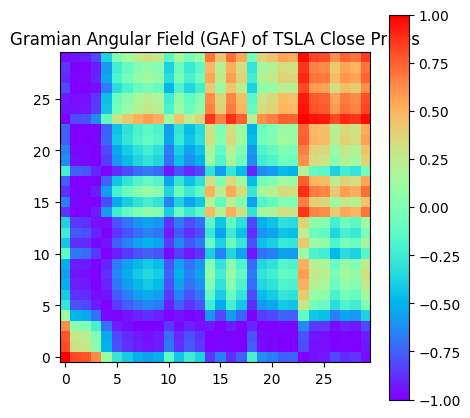

In [74]:
# Plot Sample GAF Image
plt.figure(figsize=(5, 5))
plt.imshow(gaf_images[0], cmap='rainbow', origin='lower')
plt.title("Gramian Angular Field (GAF) of TSLA Close Prices")
plt.colorbar()
plt.show()

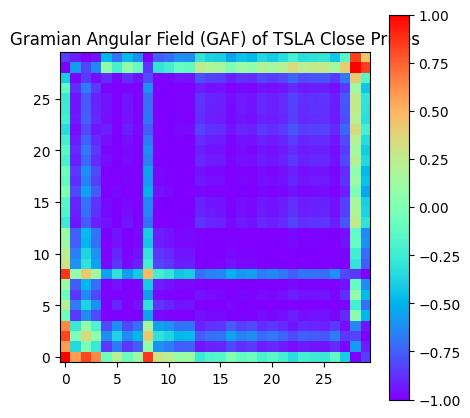

In [75]:
# Plot Sample GAF Image
plt.figure(figsize=(5, 5))
plt.imshow(gaf_images[10], cmap='rainbow', origin='lower')
plt.title("Gramian Angular Field (GAF) of TSLA Close Prices")
plt.colorbar()
plt.show()

(1202, 30)
(1202, 30, 30)


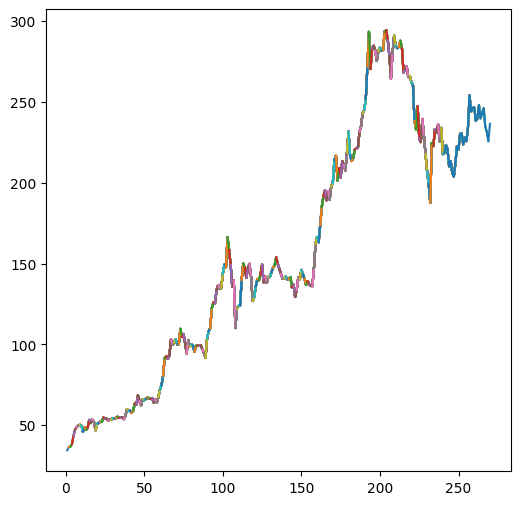

In [76]:
Xdf = df4['Close'].values
X_data=[]
X_train0 = []
X_data11=[]
window_size = 30
for i in range(window_size, Xdf.shape[0]):
    X_train0.append(Xdf[i - window_size : i])
X_train0 = np.array(X_train0)
print(X_train0.shape)
# Define a "window_size"-days interval
days = np.linspace(1, X_train0.shape[0], num=X_train0.shape[0])
# Plot the overlapping time series
plt.figure(figsize=(6, 6))
for i in range(241):
    plt.plot(days[i : window_size + i], X_train0[i,:])
transformer0 = GramianAngularField()
X_train_new0 = transformer0.transform(X_train0)
print(X_train_new0.shape)
# Determine the examples to be used as inputs in the model and rescale them to the [0,255] scale

X_data0 = X_train_new0[:-window_size]
for i in range(X_data0.shape[0]):
    X_data0[i] = (X_data0[i] - np.min(X_data0[i])) / (
        np.max(X_data0[i]) - np.min(X_data0[i])
    )
# We could simply write X_data = (X_data + 1)/2
X_data0 = X_data0 * 255
X_data0.shape
X_data=X_data0

In [77]:
X_data11=np.random.rand(X_data.shape[0],X_data.shape[1],X_data.shape[2],1)
X_data11.shape

(1172, 30, 30, 1)

In [78]:
X_data11[:, :, :, 0] = X_data

(1202, 30)


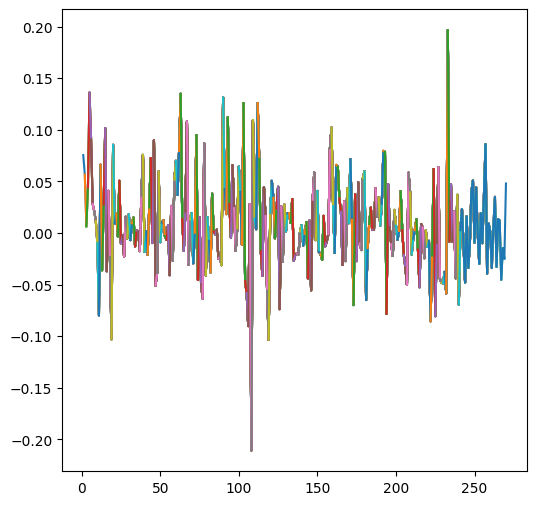

(1202, 30, 30)
(1202, 30)


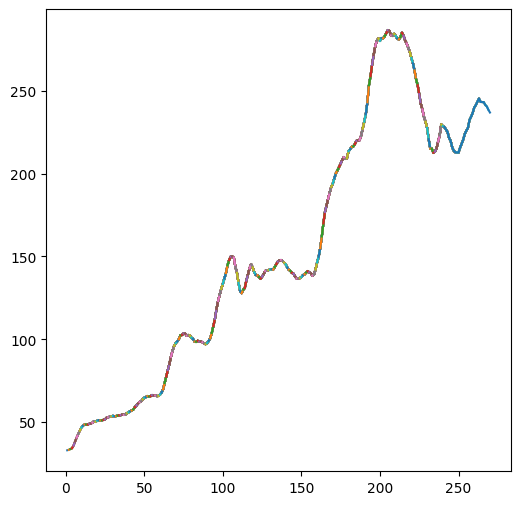

(1202, 30, 30)
(1202, 30)


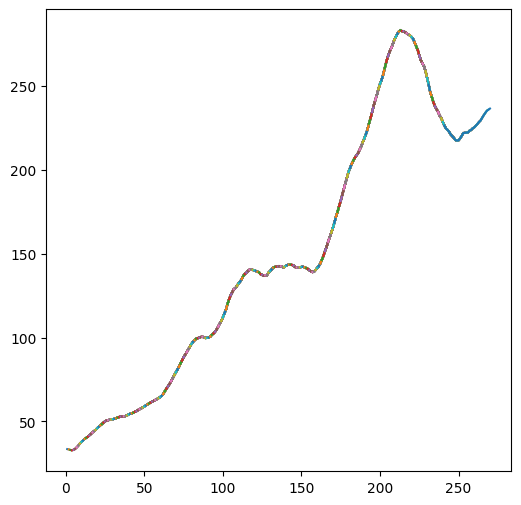

(1202, 30, 30)
(1202, 30)


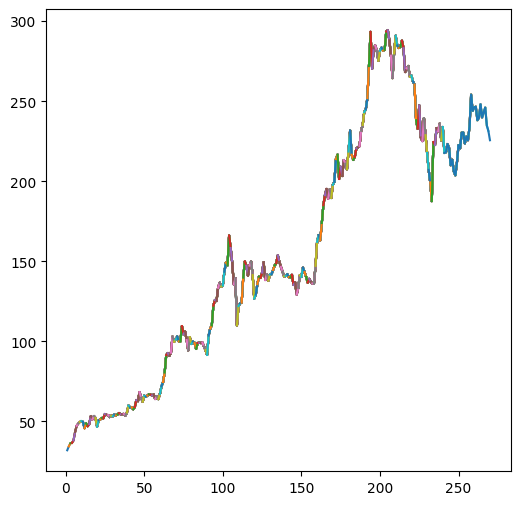

(1202, 30, 30)
(1202, 30)


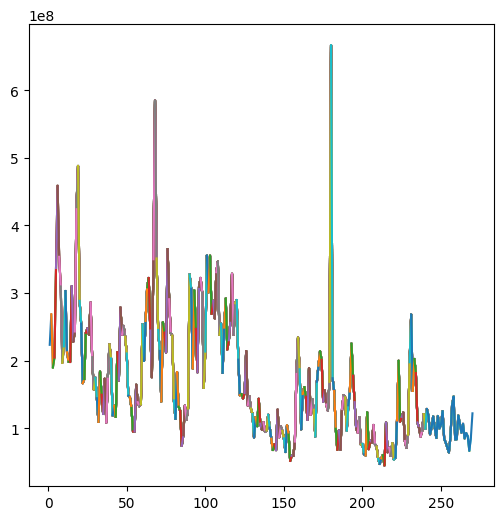

(1202, 30, 30)
(1202, 30)


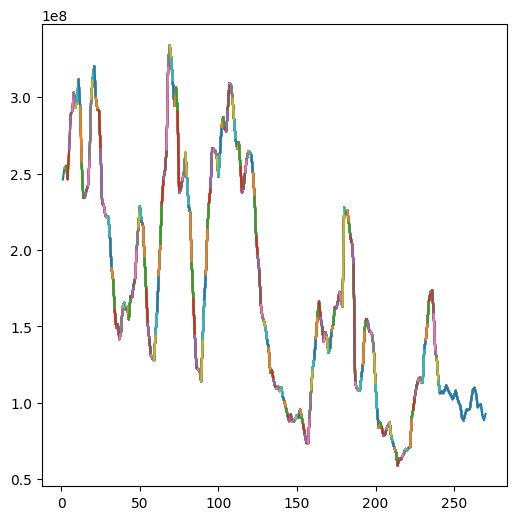

(1202, 30, 30)
(1202, 30)


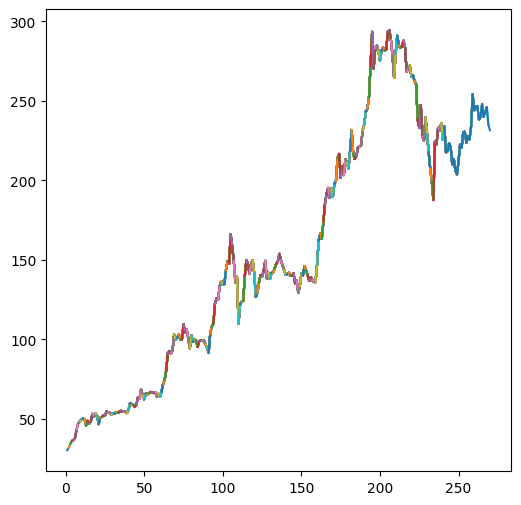

(1202, 30, 30)
(1202, 30)


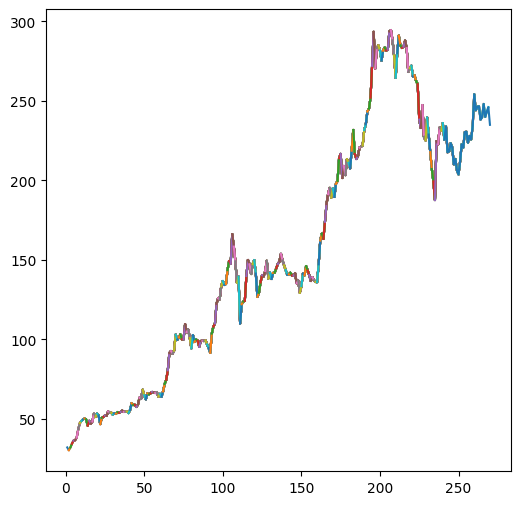

(1202, 30, 30)
(1202, 30)


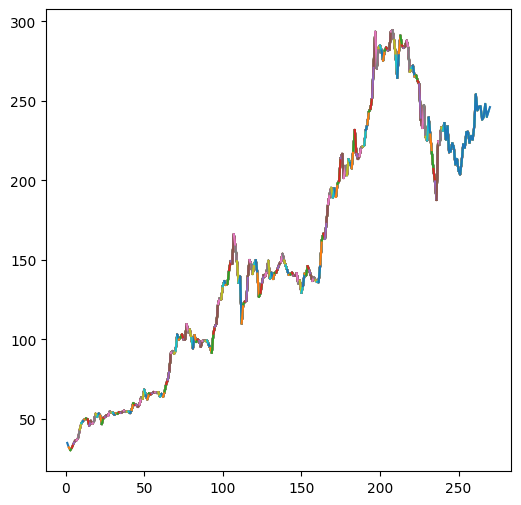

(1202, 30, 30)
(1202, 30)


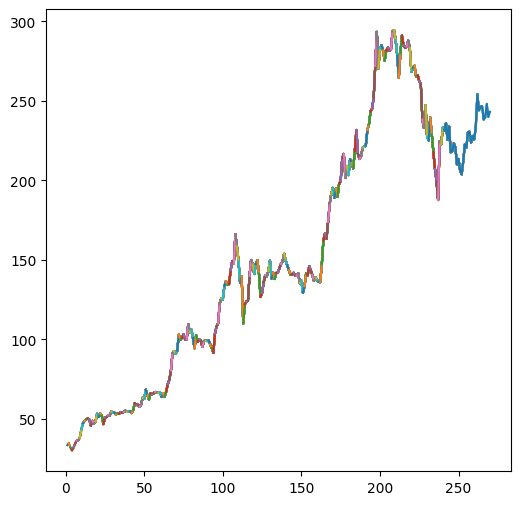

(1202, 30, 30)


In [79]:
features = ['Returns','MA7','MA21','Close_Lag_1','Volume','Volume_MA7',
            'Close_Lag_2','Close_Lag_3','Close_Lag_4','Close_Lag_5']
#X_data11=np.random.rand(X_data.shape[0],X_data.shape[1],X_data.shape[2],4)
for i,col in enumerate(features):
  Xdf2=df4[col].values
  X_train1= []
  X_data1=[]
  window_size = 30
  for i in range(window_size, Xdf2.shape[0]):
      X_train1.append(Xdf2[i - window_size : i])
  X_train1 = np.array(X_train1)
  print(X_train1.shape)
# Define a "window_size"-days interval
  days = np.linspace(1, X_train1.shape[0], num=X_train1.shape[0])
# Plot the overlapping time series
  plt.figure(figsize=(6, 6))
  for i2 in range(241):
    plt.plot(days[i2 : window_size + i2], X_train1[i2, :])
  plt.show()
  transformer1 = GramianAngularField()
  X_train_new1 = transformer1.transform(X_train1)
  print(X_train_new1.shape)
  X_data1 = X_train_new1[:-window_size]
  for i in range(X_data1.shape[0]):
      X_data1[i] = (X_data1[i] - np.min(X_data1[i])) / (
        np.max(X_data1[i]) - np.min(X_data1[i])
    )
  # We could simply write X_data = (X_data + 1)/2
  X_data1 = X_data1 * 255
  X_data1.shape
  X_data1= np.expand_dims(X_data1, axis=-1)
  # Assuming x_data0 and x_data1 have shapes (1202, 30, 30)
  X_data11 = np.concatenate((X_data11,X_data1),axis=-1)  # Add cha

In [80]:
X_data11.shape

(1172, 30, 30, 11)

(30, 30)


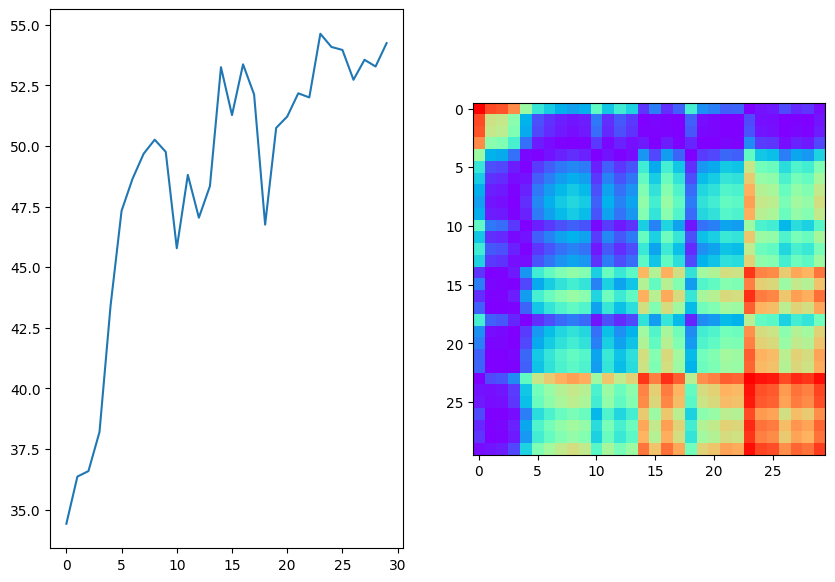

In [81]:
# Show the results for the first time series
fig, ax = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw={"width_ratios": [1, 1]})
ax[0].plot(X_train0[0, :])
ax[1].imshow(X_train_new0[0], cmap="rainbow")
print(X_train_new0[0].shape)

(30, 30)


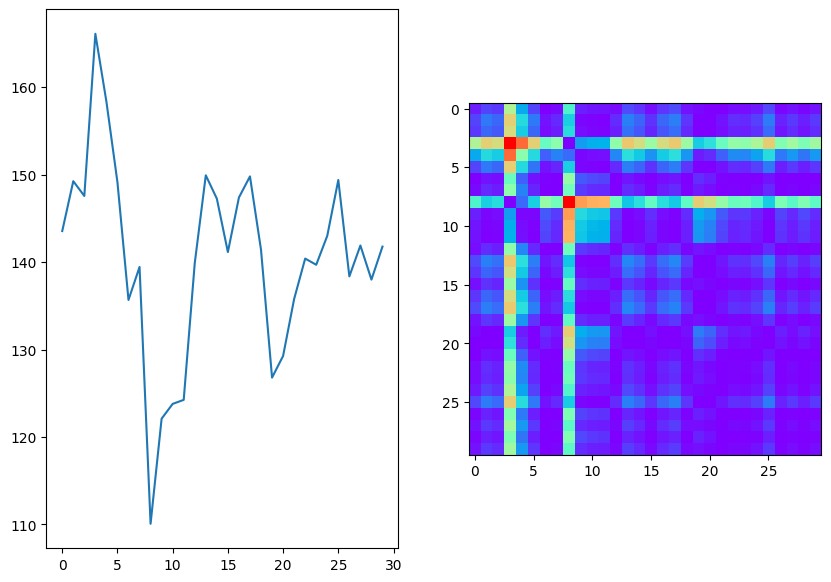

In [82]:
# Show the results for the 100th time series
fig, ax = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw={"width_ratios": [1, 1]})
ax[0].plot(X_train0[99, :])
ax[1].imshow(X_train_new0[99], cmap="rainbow")
print(X_train_new0[99].shape)

In [83]:
# Generate the labels: 1 if price goes up after window_size days, 0 otherwise
y_data = []
for i in range(window_size, Xdf.shape[0] - window_size):
    y_data.append(Xdf[i] < Xdf[i + window_size])
y_data = np.array(y_data)
y_data.shape

(1172,)

In [84]:
y_data[:5]

array([ True,  True,  True,  True,  True])

In [85]:
X_train_new0.shape

(1202, 30, 30)

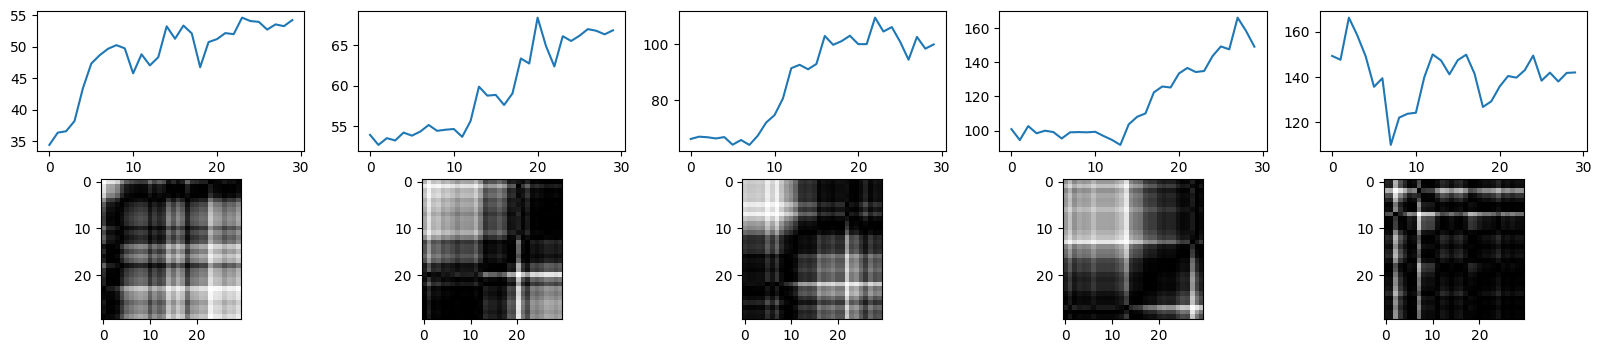

In [86]:
# display several time series and the corresponding images
fig, ax = plt.subplots(2, 5, figsize=(20, 4))
for i in range(0, 125, 25):
    ax[0, int(i / 25)].plot(X_train0[i])
for i in range(0, 125, 25):
    ax[1, int(i / 25)].imshow(X_data0[i,:], "gray")

In [87]:
# Split into train and test
train_split = 0.8
y_data_train4 = y_data[: int(train_split * y_data.shape[0])]
y_data_test4 = y_data[int(train_split * y_data.shape[0]):]
X_data_train4 = X_data11[: int(train_split * y_data.shape[0])]
X_data_test4 = X_data11[int(train_split * y_data.shape[0]):]

In [88]:
model4 = tf.keras.Sequential()
# Input layer
model4.add(tf.keras.layers.InputLayer(input_shape=(30, 30, 11)))
model4.add(tf.keras.layers.Conv2D(16, 3, activation="tanh"))
model4.add(tf.keras.layers.BatchNormalization())
model4.add(tf.keras.layers.MaxPooling2D(2))
model4.add(tf.keras.layers.Dropout(0.2, seed=1234))
model4.add(tf.keras.layers.Conv2D(32, 3, activation="tanh"))
model4.add(tf.keras.layers.BatchNormalization())
model4.add(tf.keras.layers.MaxPooling2D(2))
model4.add(tf.keras.layers.Dropout(0.2, seed=1234))
model4.add(tf.keras.layers.Conv2D(64, 3, activation="tanh"))
model4.add(tf.keras.layers.BatchNormalization())
model4.add(tf.keras.layers.MaxPooling2D(2))
model4.add(tf.keras.layers.Dropout(0.2, seed=1234))
model4.add(tf.keras.layers.Flatten())
model4.add(tf.keras.layers.Dense(1024, activation="tanh"))
model4.add(tf.keras.layers.Dropout(0.2, seed=1234))
model4.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [89]:
model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │           1,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 12, 12, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 12, 12, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1024)                │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │           1,025 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 289,377 (1.10 MB)

 Trainable params: 289,153 (1.10 MB)

 Non-trainable params: 224 (896.00 B)

In [90]:
model4.compile(loss="binary_crossentropy", optimizer="RMSprop", metrics=["accuracy"])
checkpoint4 = tf.keras.callbacks.ModelCheckpoint(
    "model41.h5", monitor="val_loss", save_best_only=True, mode="min"
)
# Add early stopping
early_stopping4 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
class_weight4 = {0: 1 / (1 - np.mean(y_data_train4)), 1: 1}
print(class_weight4)

{0: 2.134396355353075, 1: 1}


In [91]:
history4=model4.fit(
    x=X_data_train4,
    y=y_data_train4,
    epochs=50,
    validation_data=(X_data_test4, y_data_test4),
    verbose=1,
    callbacks=[checkpoint4,early_stopping4],
    class_weight=class_weight4,
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5118 - loss: 2.3956

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5121 - loss: 2.3765 - val_accuracy: 0.6170 - val_loss: 0.6554
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5191 - loss: 1.1491 - val_accuracy: 0.3234 - val_loss: 0.8666
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6031 - loss: 1.0233 - val_accuracy: 0.3447 - val_loss: 1.6098
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5998 - loss: 0.9925 - val_accuracy: 0.3404 - val_loss: 1.4781
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6423 - loss: 0.9220 - val_accuracy: 0.3702 - val_loss: 1.6538
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6056 - loss: 0.9591 - val_accuracy: 0.3617 - val_loss: 1.3802
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6514 - loss: 0.8575 - val_accuracy: 0.5660 - val_loss: 0.9060
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6969 - loss: 0.7608 - val_accuracy: 0.5660 - val_loss: 0.

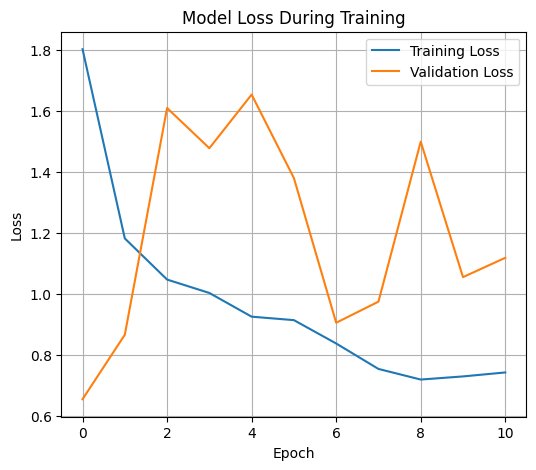

In [92]:
# Plot training history
plt.figure(figsize=(6, 5))
plt.plot(history4.history['loss'], label='Training Loss')
plt.plot(history4.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [93]:
model41 = tf.keras.models.load_model("model41.h5")
acc4 = model41.evaluate(x=X_data_test4, y=y_data_test4)
print("Accuracy over validation: {:.2f}%".format(acc4[1] * 100))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6260 - loss: 0.6477  
Accuracy over validation: 61.70%


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
              precision    recall  f1-score   support

       False       0.46      0.59      0.52        81
        True       0.75      0.63      0.68       154

    accuracy                           0.62       235
   macro avg       0.60      0.61      0.60       235
weighted avg       0.65      0.62      0.63       235



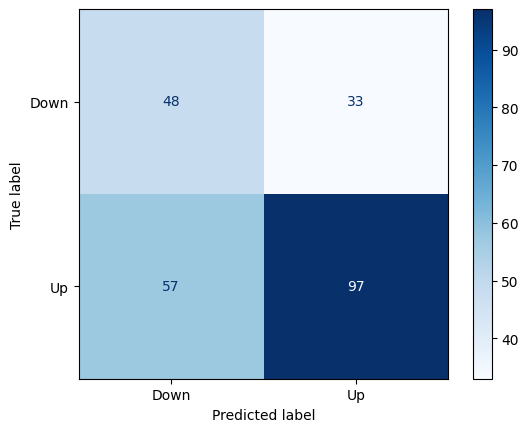

In [94]:
from sklearn import metrics
from sklearn.metrics import classification_report

y_prob4 = model41.predict(X_data_test4)
y_pred4 = np.round(y_prob4)
cm41 = metrics.confusion_matrix(y_data_test4, y_pred4)
cm41 = metrics.ConfusionMatrixDisplay(confusion_matrix=cm41, display_labels=["Down", "Up"])
cm41.plot(values_format="", cmap="Blues")
print(classification_report(y_data_test4, y_pred4))

## 3.2 GAF on TSLA Stationary Time Series for 'Close'

In [95]:
df5=df2.copy()
# Select 'Close' Prices
close_prices5 = df5['Close_Diff'].values.reshape(-1, 1)

In [96]:
df2.head(3)

,Open,High,Low,Close,Dividends,Stock Splits,Close_Diff,Returns_Diff,MA7_Diff,MA21_Diff,Volume_Diff,Volume_MA7_Diff,Close_Lag_1_Diff,Close_Lag_2_Diff,Close_Lag_3_Diff,Close_Lag_4_Diff,Close_Lag_5_Diff
Date,,,,,,,,,,,,,,,,,
2020-04-08 00:00:00-04:00,36.946667,37.147331,35.555332,36.589333,0.0,0.0,0.225998,-0.050367,0.444857,-0.306317,-78957000.0,1.409786e+06,1.947334,2.415333,1.702667,-1.806000,-2.829334
2020-04-09 00:00:00-04:00,37.472668,38.345333,37.140667,38.200001,0.0,0.0,1.610668,0.037805,0.466667,-0.194381,14910000.0,-8.831786e+06,0.225998,1.947334,2.415333,1.702667,-1.806000
2020-04-13 00:00:00-04:00,39.344002,43.466667,38.702000,43.396667,0.0,0.0,5.196667,0.092018,1.613238,0.286984,132381000.0,1.954757e+07,1.610668,0.225998,1.947334,2.415333,1.702667


(1200, 30)


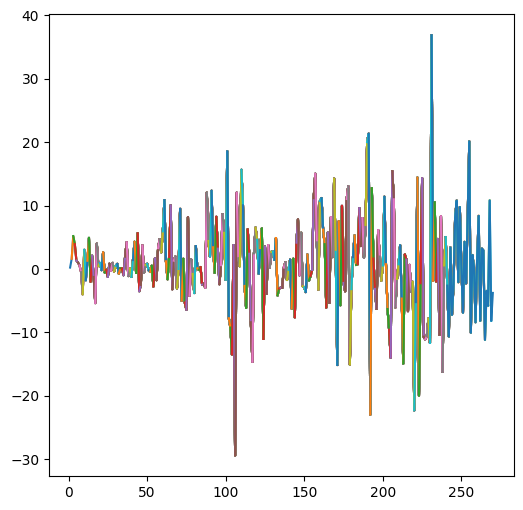

In [97]:
Xdf5 = df5['Close_Diff'].values
X_train5 = []
window_size = 30
for i in range(window_size, Xdf5.shape[0]):
    X_train5.append(Xdf5[i - window_size : i])
X_train5 = np.array(X_train5)
print(X_train5.shape)
# Define a "window_size"-days interval
days5 = np.linspace(1, X_train5.shape[0], num=X_train5.shape[0])
# Plot the overlapping time series
plt.figure(figsize=(6, 6))
for i in range(241):
    plt.plot(days5[i : window_size + i], X_train5[i, :])

In [98]:
transformer5 = GramianAngularField()
X_train_new5 = transformer5.transform(X_train5)
print(X_train_new5.shape)

(1200, 30, 30)


(30, 30)


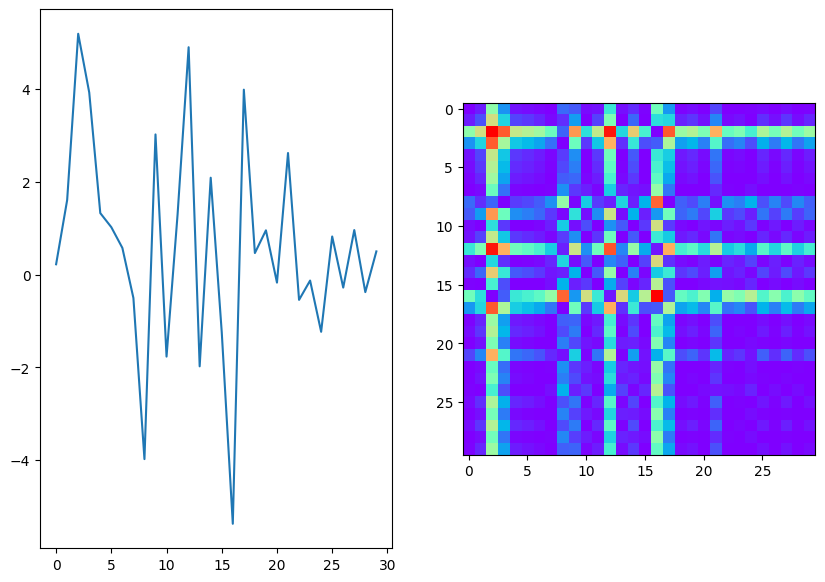

In [99]:
# Show the results for the first time series
fig, ax = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw={"width_ratios": [1, 1]})
ax[0].plot(X_train5[0, :])
ax[1].imshow(X_train_new5[0], cmap="rainbow")
print(X_train_new5[0].shape)

(30, 30)


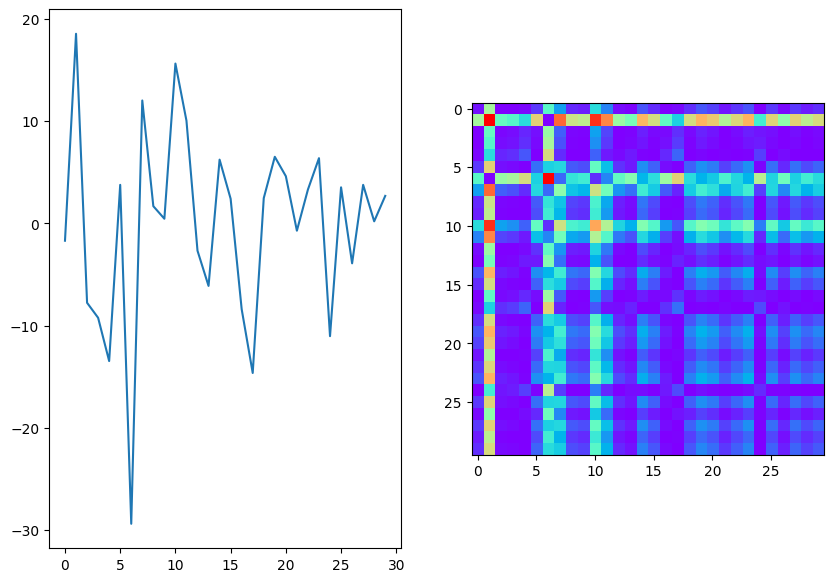

In [100]:
# Show the results for the 100th time series
fig, ax = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw={"width_ratios": [1, 1]})
ax[0].plot(X_train5[99, :])
ax[1].imshow(X_train_new5[99], cmap="rainbow")
print(X_train_new5[99].shape)

In [101]:
# Generate the labels: 1 if price goes up after window_size days, 0 otherwise
y_data5 = []
for i in range(window_size, Xdf5.shape[0] - window_size):
    y_data5.append(Xdf5[i] < Xdf5[i + window_size])
y_data5 = np.array(y_data5)
y_data5.shape

(1170,)

In [102]:
# Determine the examples to be used as inputs in the model and rescale them to the [0,255] scale
X_data5 = X_train_new5[:-window_size]
for i in range(X_data5.shape[0]):
    X_data5[i] = (X_data5[i] - np.min(X_data5[i])) / (
        np.max(X_data5[i]) - np.min(X_data5[i])
    )
# We could simply write X_data = (X_data + 1)/2
X_data5 = X_data5 * 255
X_data5.shape

(1170, 30, 30)

In [103]:
X_data52=[]
X_data52=np.random.rand(X_data5.shape[0],X_data5.shape[1],X_data5.shape[2],1)
X_data52.shape

(1170, 30, 30, 1)

In [104]:
X_data52[:, :, :, 0] = X_data5

(1200, 30)


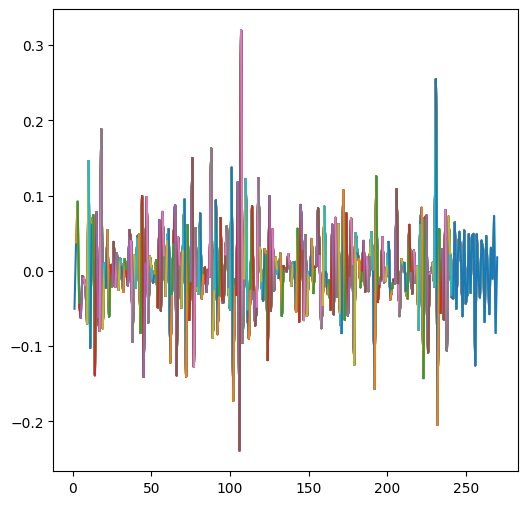

(1200, 30, 30)
(1200, 30)


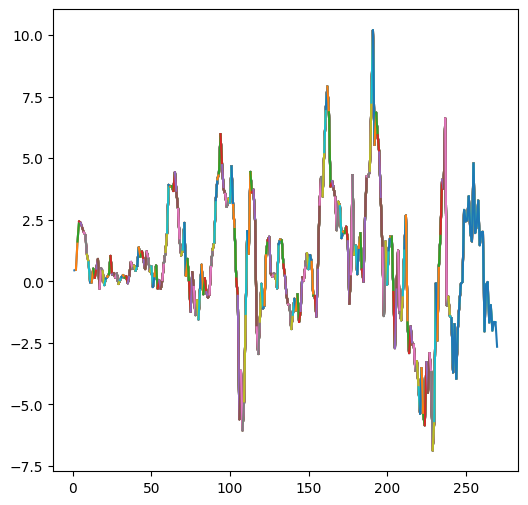

(1200, 30, 30)
(1200, 30)


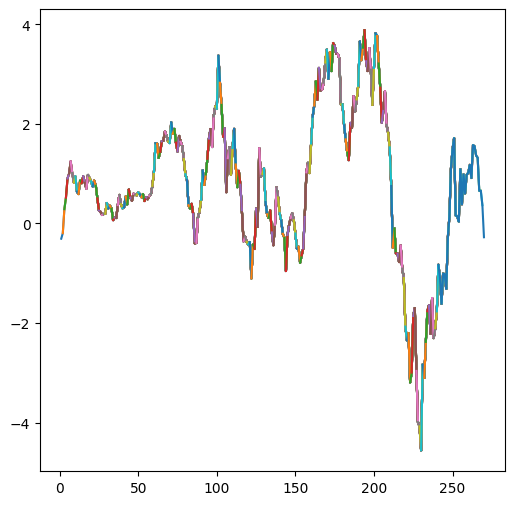

(1200, 30, 30)
(1200, 30)


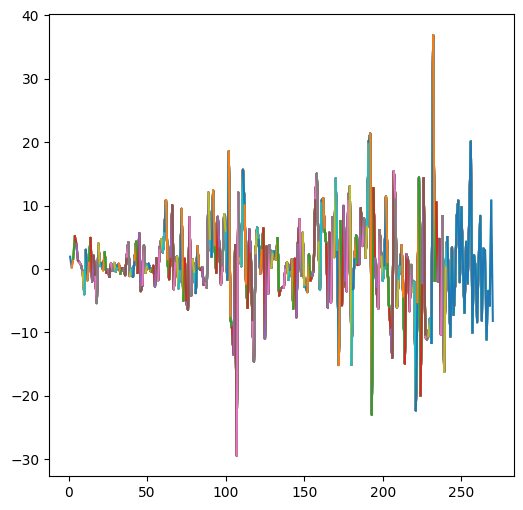

(1200, 30, 30)
(1200, 30)


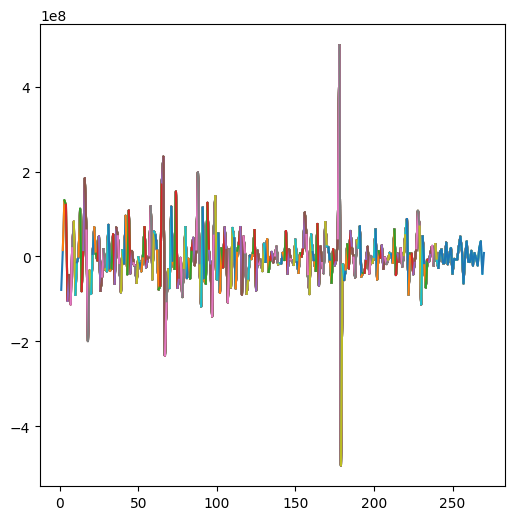

(1200, 30, 30)
(1200, 30)


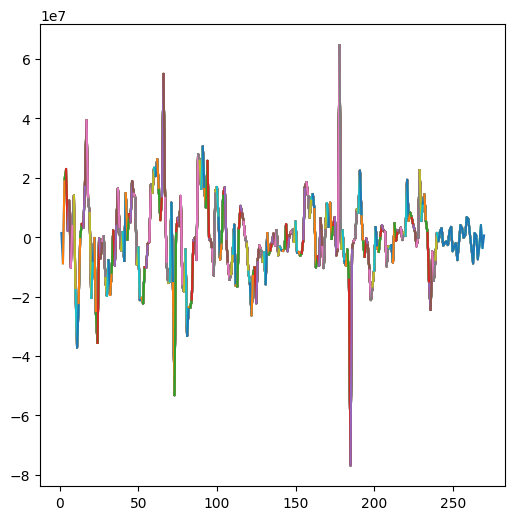

(1200, 30, 30)
(1200, 30)


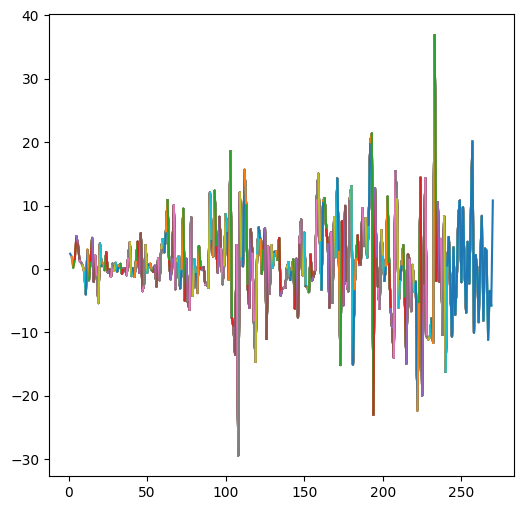

(1200, 30, 30)
(1200, 30)


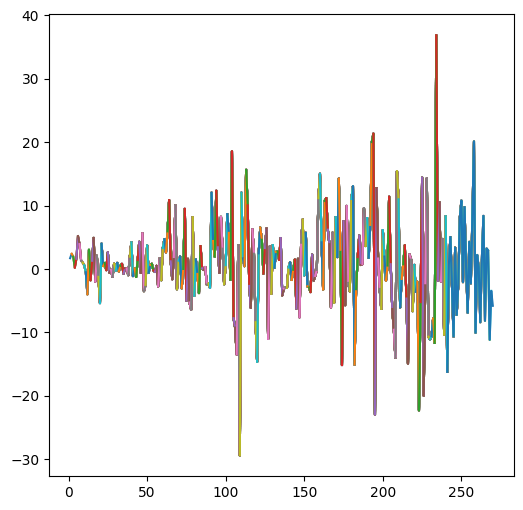

(1200, 30, 30)
(1200, 30)


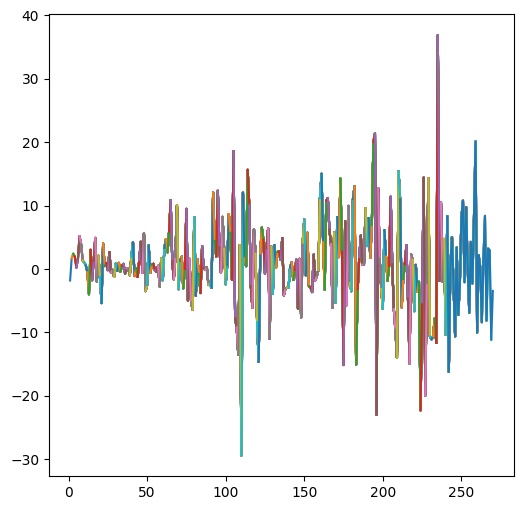

(1200, 30, 30)
(1200, 30)


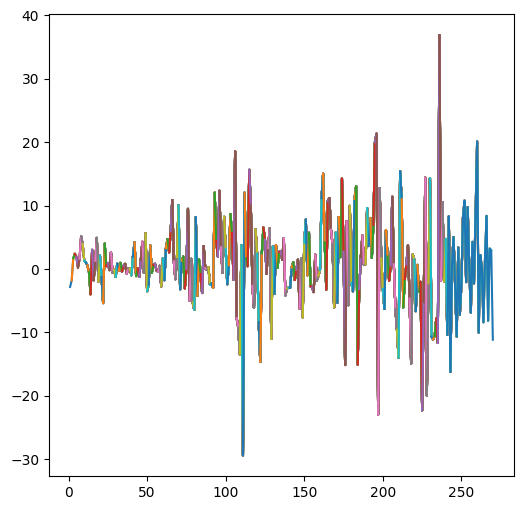

(1200, 30, 30)


In [105]:
features = ['Returns_Diff','MA7_Diff','MA21_Diff','Close_Lag_1_Diff','Volume_Diff','Volume_MA7_Diff',
            'Close_Lag_2_Diff','Close_Lag_3_Diff','Close_Lag_4_Diff','Close_Lag_5_Diff']
#X_data11=np.random.rand(X_data.shape[0],X_data.shape[1],X_data.shape[2],4)
for i,col in enumerate(features):
  Xdf51=df5[col].values
  X_train51= []
  X_data51=[]
  window_size = 30
  for i in range(window_size, Xdf51.shape[0]):
      X_train51.append(Xdf51[i - window_size : i])
  X_train51 = np.array(X_train51)
  print(X_train51.shape)
# Define a "window_size"-days interval
  days = np.linspace(1, X_train51.shape[0], num=X_train51.shape[0])
# Plot the overlapping time series
  plt.figure(figsize=(6, 6))
  for i2 in range(241):
    plt.plot(days[i2 : window_size + i2], X_train51[i2, :])
  plt.show()
  transformer51 = GramianAngularField()
  X_train_new51 = transformer51.transform(X_train51)
  print(X_train_new51.shape)
  X_data51 = X_train_new51[:-window_size]
  for i in range(X_data51.shape[0]):
      X_data51[i] = (X_data51[i] - np.min(X_data51[i])) / (
        np.max(X_data51[i]) - np.min(X_data51[i])
    )
  # We could simply write X_data = (X_data + 1)/2
  X_data51 = X_data51 * 255
  X_data51.shape
  X_data51= np.expand_dims(X_data51, axis=-1)
  # Assuming x_data0 and x_data1 have shapes (1202, 30, 30)
  X_data52 = np.concatenate((X_data52,X_data51),axis=-1)  # Add cha

In [106]:
X_data52.shape

(1170, 30, 30, 11)

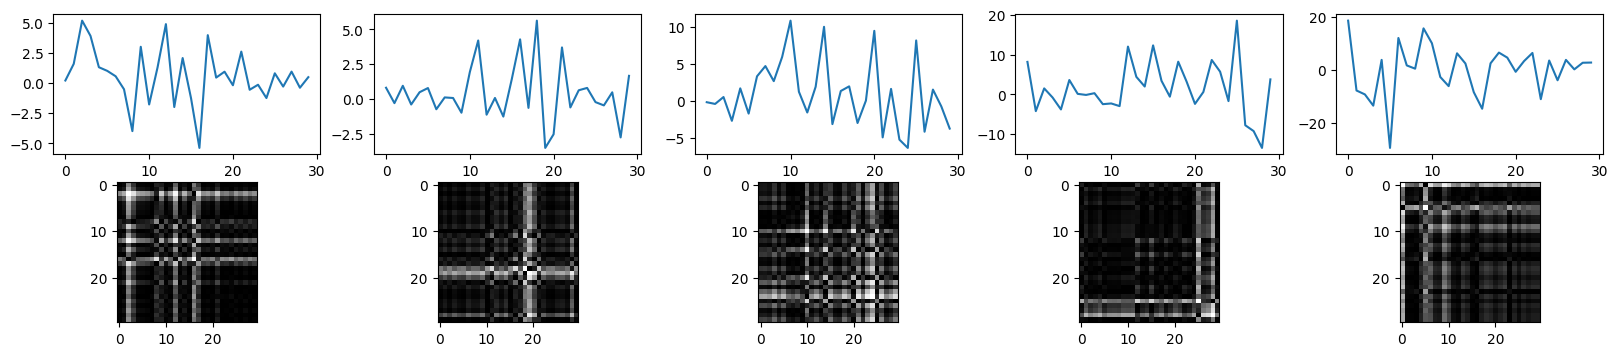

In [107]:
# display several time series and the corresponding images
fig, ax = plt.subplots(2, 5, figsize=(20, 4))
for i in range(0, 125, 25):
    ax[0, int(i / 25)].plot(X_train5[i])
for i in range(0, 125, 25):
    ax[1, int(i / 25)].imshow(X_data5[i], "gray")

In [108]:
# Split into train and test
train_split = 0.8
y_data_train5 = y_data5[: int(train_split * y_data5.shape[0])]
y_data_test5 = y_data5[int(train_split * y_data5.shape[0]) :]
X_data_train5 = X_data52[: int(train_split * y_data5.shape[0])]
X_data_test5 = X_data52[int(train_split * y_data5.shape[0]) :]

In [109]:
# model5 = tf.keras.Sequential()
# # Input layer
# model5.add(tf.keras.layers.InputLayer(input_shape=(30, 30, 11)))
# model5.add(tf.keras.layers.Conv2D(16, 3))
# model5.add(tf.keras.layers.BatchNormalization())
# model5.add(tf.keras.layers.Activation('tanh'))
# model5.add(tf.keras.layers.MaxPooling2D(2))

# model5.add(tf.keras.layers.Conv2D(32, 3))
# model5.add(tf.keras.layers.BatchNormalization())
# model5.add(tf.keras.layers.Activation('tanh'))
# model5.add(tf.keras.layers.MaxPooling2D(2))

# model5.add(tf.keras.layers.Conv2D(64, 3))
# model5.add(tf.keras.layers.BatchNormalization())
# model5.add(tf.keras.layers.Activation('tanh'))
# model5.add(tf.keras.layers.MaxPooling2D(2))
# model5.add(tf.keras.layers.Conv2D(128, 3))
# model5.add(tf.keras.layers.BatchNormalization())
# model5.add(tf.keras.layers.Activation('tanh'))
# model5.add(tf.keras.layers.MaxPooling2D(2))

# model5.add(tf.keras.layers.MaxPooling2D(2))
# model5.add(tf.keras.layers.Dropout(0.3, seed=1234))
# model5.add(tf.keras.layers.Flatten())
# model5.add(tf.keras.layers.Dense(512))
# model5.add(tf.keras.layers.Dropout(0.3, seed=1234))
# model5.add(tf.keras.layers.Dense(1024))
# model5.add(tf.keras.layers.Dropout(0.3, seed=1234))
# model5.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [110]:
model5 = tf.keras.Sequential()

# Input layer
model5.add(tf.keras.layers.InputLayer(input_shape=(30, 30, 11)))

# Conv Block 1
model5.add(tf.keras.layers.Conv2D(32, (3,3), strides=1, padding="same"))
model5.add(tf.keras.layers.BatchNormalization())
model5.add(tf.keras.layers.Activation('tanh'))
model5.add(tf.keras.layers.MaxPooling2D((2,2)))

# Conv Block 2
model5.add(tf.keras.layers.Conv2D(64, (3,3), strides=1, padding="same"))
model5.add(tf.keras.layers.BatchNormalization())
model5.add(tf.keras.layers.Activation('tanh'))
model5.add(tf.keras.layers.MaxPooling2D((2,2)))

# Conv Block 3
model5.add(tf.keras.layers.Conv2D(128, (3,3), strides=1, padding="same"))
model5.add(tf.keras.layers.BatchNormalization())
model5.add(tf.keras.layers.Activation('tanh'))
model5.add(tf.keras.layers.GlobalAveragePooling2D())  # Smaller feature map at the end

model5.add(tf.keras.layers.Dropout(0.3, seed=1234))
model5.add(tf.keras.layers.Flatten())
model5.add(tf.keras.layers.Dense(512))
model5.add(tf.keras.layers.Dropout(0.3, seed=1234))
model5.add(tf.keras.layers.Dense(1024))
model5.add(tf.keras.layers.Dropout(0.3, seed=1234))
model5.add(tf.keras.layers.Dense(1, activation="sigmoid"))



In [111]:
model5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 32)          │           3,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 15, 15, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 15, 15, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 512)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1024)                │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │           1,025 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 688,833 (2.63 MB)

 Trainable params: 688,385 (2.63 MB)

 Non-trainable params: 448 (1.75 KB)

In [112]:
model5.compile(loss="binary_crossentropy", optimizer="RMSprop", metrics=["accuracy"])
checkpoint5 = tf.keras.callbacks.ModelCheckpoint(
    "model51.h5", monitor="val_loss", save_best_only=True, mode="min"
)
# Add early stopping
early_stopping5 = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

class_weight5 = {0: 1.3 , 1: 1}
print(class_weight5)

{0: 1.3, 1: 1}


In [113]:
history5=model5.fit(
    x=X_data_train5,
    y=y_data_train5,
    epochs=50,
    validation_data=(X_data_test5, y_data_test5),
    verbose=1,
    callbacks=[checkpoint5,early_stopping5],
    class_weight=class_weight5,
)

Epoch 1/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4943 - loss: 1.0676

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.4947 - loss: 1.0606 - val_accuracy: 0.5128 - val_loss: 0.7083
Epoch 2/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5096 - loss: 0.8387

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.5094 - loss: 0.8389 - val_accuracy: 0.5470 - val_loss: 0.6984
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5272 - loss: 0.8081 - val_accuracy: 0.4786 - val_loss: 2.1850
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5482 - loss: 0.8104 - val_accuracy: 0.4829 - val_loss: 0.7983
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.6382 - loss: 0.7589 - val_accuracy: 0.4530 - val_loss: 0.8004
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6029 - loss: 0.7420 - val_accuracy: 0.4786 - val_loss: 0.9365
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6710 - loss: 0.6828 - val_accuracy: 0.5214 - val_loss: 1.6075
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.7349 - loss: 0.6144 - val_accuracy: 0.5085 - val_loss: 1.4352
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7394 - loss: 0.6060 - val_accuracy: 0.5171 - val_loss: 3.

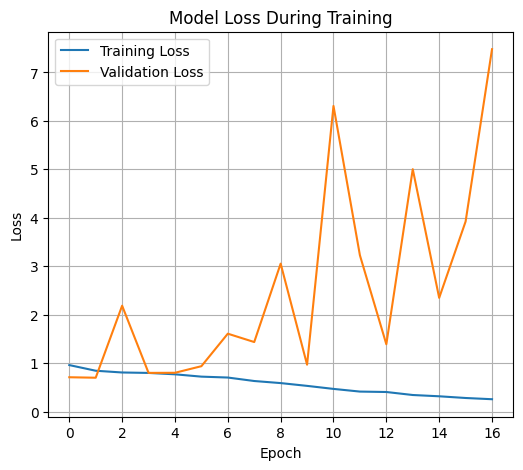

In [114]:
# Plot training history
plt.figure(figsize=(6, 5))
plt.plot(history5.history['loss'], label='Training Loss')
plt.plot(history5.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [115]:
model51 = tf.keras.models.load_model("model51.h5")
acc5 = model51.evaluate(x=X_data_test5, y=y_data_test5)
print("Accuracy over validation: {:.2f}%".format(acc5[1] * 100))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5355 - loss: 0.7026
Accuracy over validation: 54.70%


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
              precision    recall  f1-score   support

       False       0.54      0.93      0.68       122
        True       0.64      0.12      0.21       112

    accuracy                           0.55       234
   macro avg       0.59      0.53      0.45       234
weighted avg       0.58      0.55      0.46       234



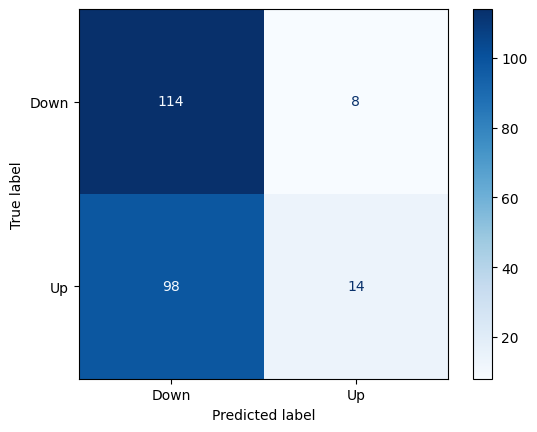

In [116]:
y_prob5 = model5.predict(X_data_test5)
y_pred5 = np.round(y_prob5)
cm = metrics.confusion_matrix(y_data_test5, y_pred5)
cm = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
cm.plot(values_format="", cmap="Blues")
print(classification_report(y_data_test5, y_pred5))

## Step 3.3 GAF on TSLA Fractionally Differenced Time Series for 'Close'

In [117]:
df6=df3.copy()
# Select 'Close' Prices
close_prices6 = df6['Close_FD'].values.reshape(-1, 1)

In [118]:
Xdf6 = df6['Close_FD'].values
X_train6 = []
window_size = 30

(1103, 30)


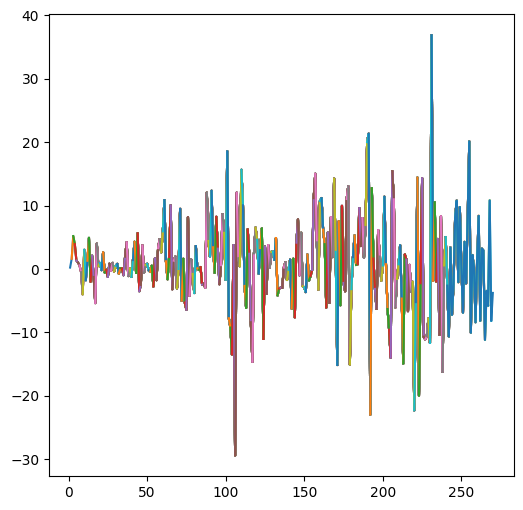

In [119]:
X_train6 = []
window_size = 30
for i in range(window_size, Xdf6.shape[0]):
    X_train6.append(Xdf5[i - window_size : i])
X_train6 = np.array(X_train6)
print(X_train6.shape)
# Define a "window_size"-days interval
days6 = np.linspace(1, X_train6.shape[0], num=X_train6.shape[0])
# Plot the overlapping time series
plt.figure(figsize=(6, 6))
for i in range(241):
    plt.plot(days6[i : window_size + i], X_train6[i, :])

In [120]:
transformer6 = GramianAngularField()
X_train_new6 = transformer6.transform(X_train6)
print(X_train_new6.shape)

(1103, 30, 30)


(30, 30)


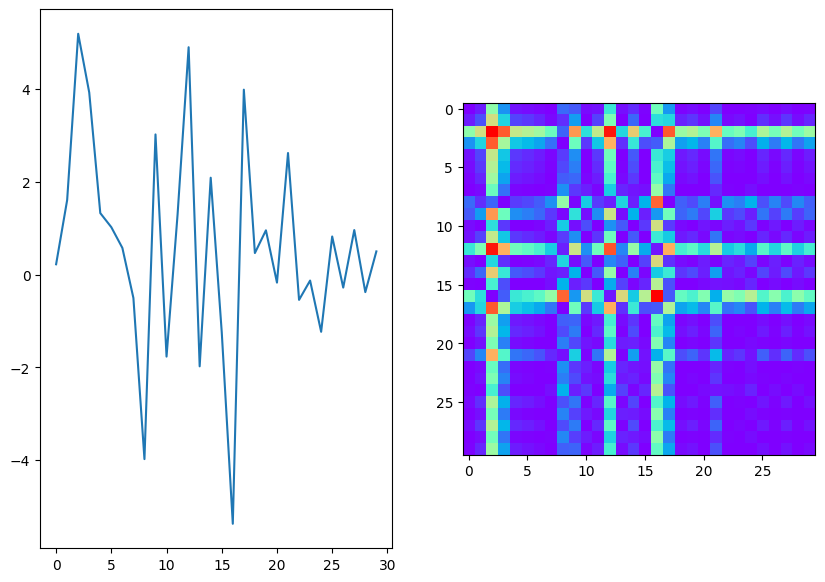

In [121]:
# Show the results for the first time series
fig, ax = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw={"width_ratios": [1, 1]})
ax[0].plot(X_train6[0, :])
ax[1].imshow(X_train_new6[0], cmap="rainbow")
print(X_train_new6[0].shape)

(30, 30)


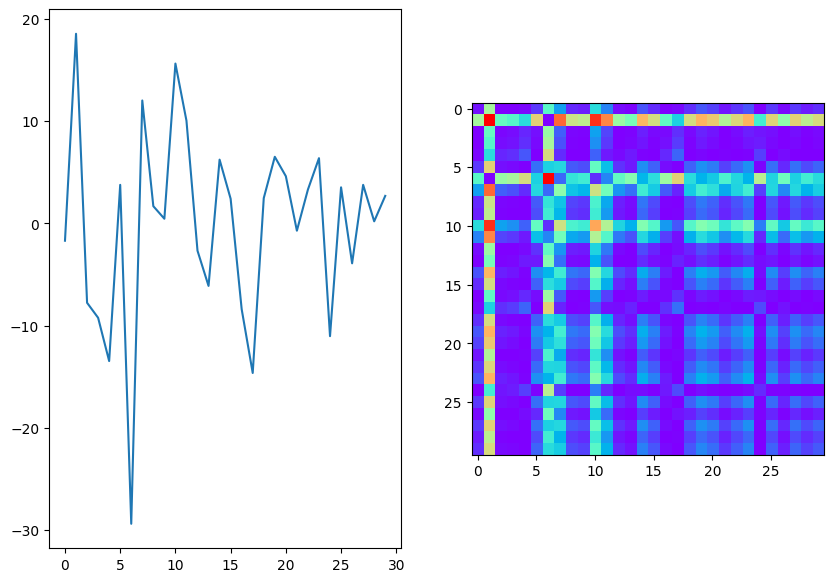

In [122]:
# Show the results for the 100th time series
fig, ax = plt.subplots(1, 2, figsize=(10, 7), gridspec_kw={"width_ratios": [1, 1]})
ax[0].plot(X_train6[99, :])
ax[1].imshow(X_train_new6[99], cmap="rainbow")
print(X_train_new6[99].shape)

In [123]:
# Generate the labels: 1 if price goes up after window_size days, 0 otherwise
y_data6 = []
for i in range(window_size, Xdf6.shape[0] - window_size):
    y_data6.append(Xdf5[i] < Xdf6[i + window_size])
y_data6 = np.array(y_data6)
y_data6.shape

(1073,)

In [124]:
# Determine the examples to be used as inputs in the model and rescale them to the [0,255] scale
X_data6 = X_train_new6[:-window_size]
for i in range(X_data6.shape[0]):
    X_data6[i] = (X_data6[i] - np.min(X_data6[i])) / (
        np.max(X_data6[i]) - np.min(X_data6[i])
    )
# We could simply write X_data = (X_data + 1)/2
X_data6 = X_data6 * 255
X_data6.shape

(1073, 30, 30)

In [125]:
X_data62=[]
X_data62=np.random.rand(X_data6.shape[0],X_data6.shape[1],X_data6.shape[2],1)
X_data62.shape

(1073, 30, 30, 1)

In [126]:
X_data62[:, :, :, 0] = X_data6

In [127]:
X_data62.shape

(1073, 30, 30, 1)

(1103, 30)


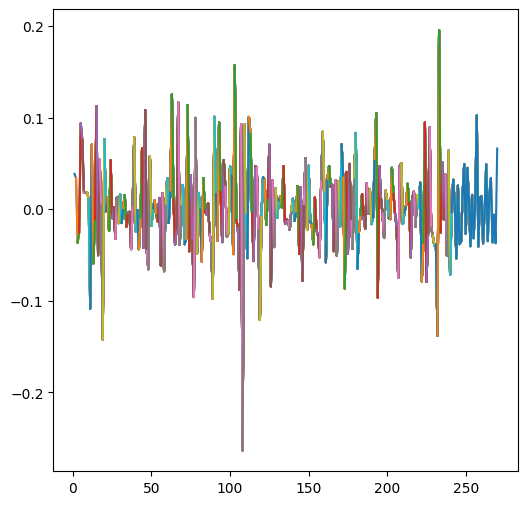

(1103, 30, 30)
(1103, 30)


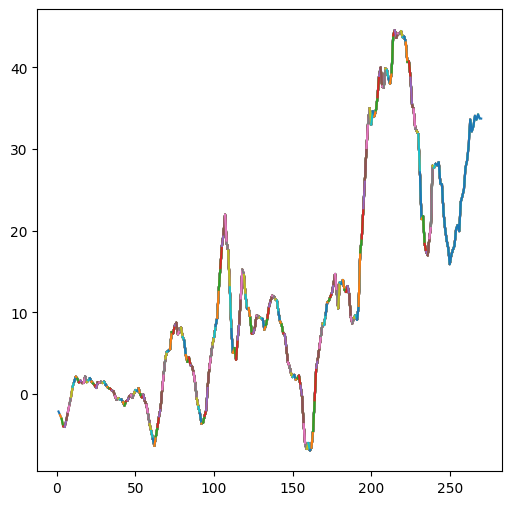

(1103, 30, 30)
(1103, 30)


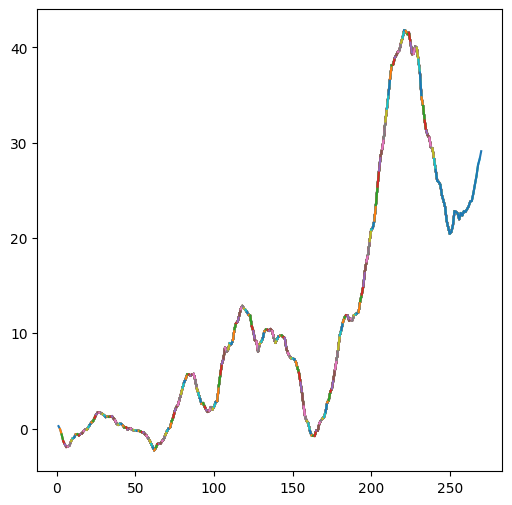

(1103, 30, 30)
(1103, 30)


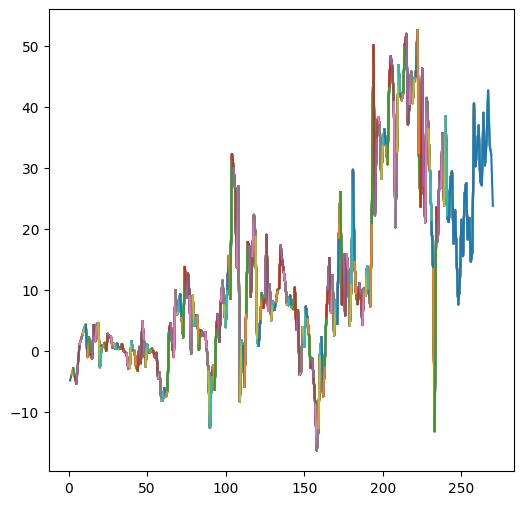

(1103, 30, 30)
(1103, 30)


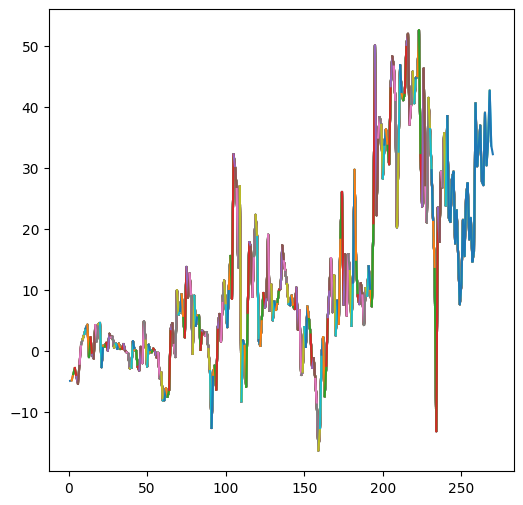

(1103, 30, 30)
(1103, 30)


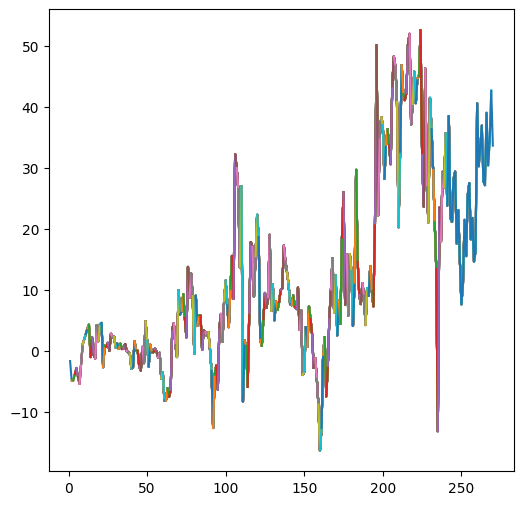

(1103, 30, 30)
(1103, 30)


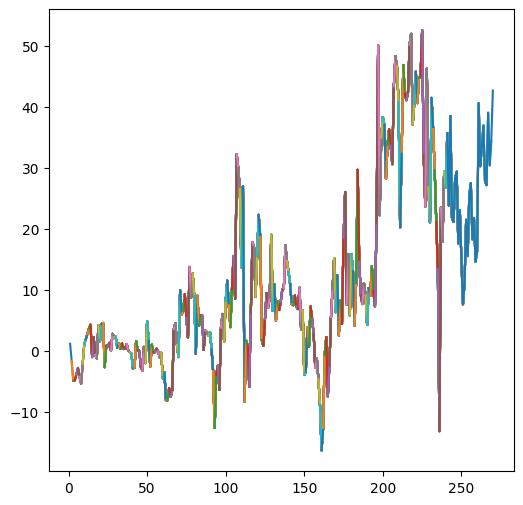

(1103, 30, 30)
(1103, 30)


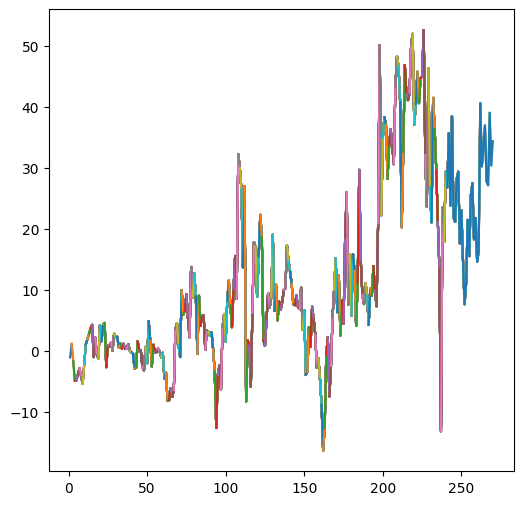

(1103, 30, 30)


In [128]:
features6 = ['Returns_FD','MA7_FD','MA21_FD','Close_Lag_1_FD',
            'Close_Lag_2_FD','Close_Lag_3_FD','Close_Lag_4_FD','Close_Lag_5_FD']
#X_data11=np.random.rand(X_data.shape[0],X_data.shape[1],X_data.shape[2],4)
for i,col in enumerate(features6):
  Xdf61=df6[col].values
  X_train61= []
  X_data61=[]
  window_size = 30
  for i in range(window_size, Xdf61.shape[0]):
      X_train61.append(Xdf61[i - window_size : i])
  X_train61 = np.array(X_train61)
  print(X_train61.shape)
# Define a "window_size"-days interval
  days = np.linspace(1, X_train61.shape[0], num=X_train61.shape[0])
# Plot the overlapping time series
  plt.figure(figsize=(6, 6))
  for i2 in range(241):
    plt.plot(days[i2 : window_size + i2], X_train61[i2, :])
  plt.show()
  transformer61 = GramianAngularField()
  X_train_new61 = transformer61.transform(X_train61)
  print(X_train_new61.shape)
  X_data61 = X_train_new61[:-window_size]
  for i in range(X_data61.shape[0]):
      X_data61[i] = (X_data61[i] - np.min(X_data61[i])) / (
        np.max(X_data61[i]) - np.min(X_data61[i])
    )
  # We could simply write X_data = (X_data + 1)/2
  X_data61 = X_data61 * 255
  X_data61.shape
  X_data61= np.expand_dims(X_data61, axis=-1)
  # Assuming x_data0 and x_data1 have shapes (1202, 30, 30)
  X_data62 = np.concatenate((X_data62,X_data61),axis=-1)  # Add cha

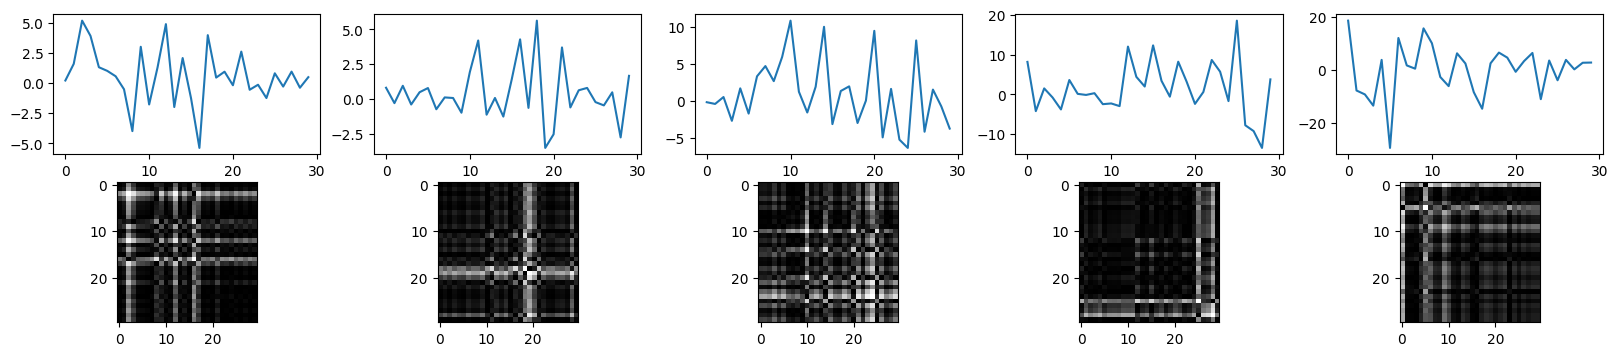

In [129]:
# display several time series and the corresponding images
fig, ax = plt.subplots(2, 5, figsize=(20, 4))
for i in range(0, 125, 25):
    ax[0, int(i / 25)].plot(X_train6[i])
for i in range(0, 125, 25):
    ax[1, int(i / 25)].imshow(X_data6[i], "gray")

In [130]:
## Split into train and test
train_split = 0.8
y_data_train6 = y_data6[: int(train_split * y_data6.shape[0])]
y_data_test6 = y_data6[int(train_split * y_data6.shape[0]) :]
X_data_train6 = X_data62[: int(train_split * y_data6.shape[0])]
X_data_test6 = X_data62[int(train_split * y_data6.shape[0]) :]

In [131]:
model6 = tf.keras.Sequential()
# Input layer
model6.add(tf.keras.layers.InputLayer(input_shape=(30, 30, 9)))
model6.add(tf.keras.layers.Conv2D(16, 3, activation="tanh"))
model6.add(tf.keras.layers.BatchNormalization())
model6.add(tf.keras.layers.MaxPooling2D(2))
model6.add(tf.keras.layers.Dropout(0.2, seed=1234))
model6.add(tf.keras.layers.Conv2D(32, 3, activation="tanh"))
model6.add(tf.keras.layers.BatchNormalization())
model6.add(tf.keras.layers.MaxPooling2D(2))
model6.add(tf.keras.layers.Dropout(0.2, seed=1234))
model6.add(tf.keras.layers.Conv2D(64, 3, activation="tanh"))
model6.add(tf.keras.layers.BatchNormalization())
model6.add(tf.keras.layers.MaxPooling2D(2))
model6.add(tf.keras.layers.Dropout(0.2, seed=1234))
model6.add(tf.keras.layers.Flatten())
model6.add(tf.keras.layers.Dense(1024, activation="tanh"))
model6.add(tf.keras.layers.Dropout(0.2, seed=1234))
model6.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [132]:
model6.compile(loss="binary_crossentropy", optimizer="RMSprop", metrics=["accuracy"])
checkpoint6 = tf.keras.callbacks.ModelCheckpoint(
    "model61.h5", monitor="val_loss", save_best_only=True, mode="min"
)
# Add early stopping
early_stopping6 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
class_weight6 = {0: 1 / (1 - np.mean(y_data_train6)) , 1: 1}
print(class_weight6)

{0: 11.753424657534254, 1: 1}


In [133]:
history6=model6.fit(
    x=X_data_train6,
    y=y_data_train6,
    epochs=50,
    validation_data=(X_data_test6, y_data_test6),
    verbose=1,
    callbacks=[checkpoint6,early_stopping6],
    class_weight=class_weight6,
)

Epoch 1/50
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5827 - loss: 3.2332

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5763 - loss: 3.1893 - val_accuracy: 0.0837 - val_loss: 1.7982
Epoch 2/50
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5898 - loss: 1.5481

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5875 - loss: 1.5693 - val_accuracy: 0.4651 - val_loss: 0.7533
Epoch 3/50
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5806 - loss: 1.6778

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5765 - loss: 1.6943 - val_accuracy: 0.6837 - val_loss: 0.5712
Epoch 4/50
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6026 - loss: 1.6934

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6027 - loss: 1.6850 - val_accuracy: 0.7860 - val_loss: 0.5063
Epoch 5/50
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5499 - loss: 1.6071

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5481 - loss: 1.6100 - val_accuracy: 0.8791 - val_loss: 0.4062
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6631 - loss: 1.2789 - val_accuracy: 0.6744 - val_loss: 0.6210
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5787 - loss: 1.4300

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5785 - loss: 1.4333 - val_accuracy: 0.8977 - val_loss: 0.3469
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5517 - loss: 1.6294 - val_accuracy: 0.4279 - val_loss: 0.8631
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5197 - loss: 1.5845 - val_accuracy: 0.8837 - val_loss: 0.3547
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6231 - loss: 1.3039 - val_accuracy: 0.7442 - val_loss: 0.5332
Epoch 11/50
25/27 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6293 - loss: 1.3345

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6287 - loss: 1.3378 - val_accuracy: 0.8837 - val_loss: 0.3150
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6258 - loss: 1.2830 - val_accuracy: 0.9163 - val_loss: 0.4063
Epoch 13/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6370 - loss: 1.3157 - val_accuracy: 0.9163 - val_loss: 0.4710
Epoch 14/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6519 - loss: 1.3108 - val_accuracy: 0.9023 - val_loss: 0.3998
Epoch 15/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5934 - loss: 1.3552 - val_accuracy: 0.9163 - val_loss: 0.4205
Epoch 16/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5996 - loss: 1.3465 - val_accuracy: 0.9163 - val_loss: 0.4769
Epoch 17/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7097 - loss: 1.0835 - val_accuracy: 0.9070 - val_loss: 0.5198
Epoch 18/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7931 - loss: 0.8704 - val_accuracy: 0.9163 - val_l

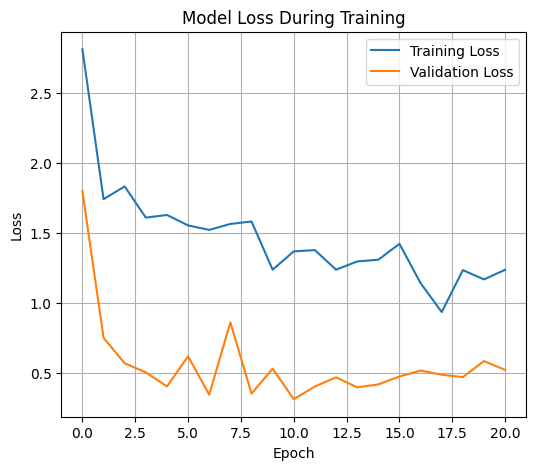

In [134]:
# Plot training history
plt.figure(figsize=(6, 5))
plt.plot(history6.history['loss'], label='Training Loss')
plt.plot(history6.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [135]:
model61 = tf.keras.models.load_model("model61.h5")
acc6 = model61.evaluate(x=X_data_test6, y=y_data_test6)
print("Accuracy over validation: {:.2f}%".format(acc6[1] * 100))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9299 - loss: 0.1939 
Accuracy over validation: 88.37%


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
              precision    recall  f1-score   support

       False       0.00      0.00      0.00        18
        True       0.91      0.96      0.94       197

    accuracy                           0.88       215
   macro avg       0.46      0.48      0.47       215
weighted avg       0.84      0.88      0.86       215



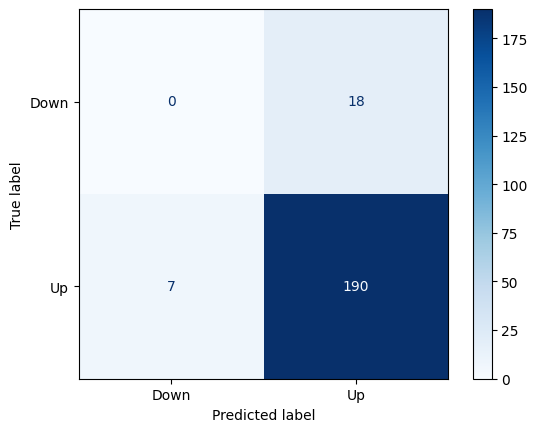

In [136]:
y_prob6 = model6.predict(X_data_test6)
y_pred6 = np.round(y_prob6)
cm6 = metrics.confusion_matrix(y_data_test6, y_pred6)
cm6 = metrics.ConfusionMatrixDisplay(confusion_matrix=cm6, display_labels=["Down", "Up"])
cm6.plot(values_format="", cmap="Blues")
print(classification_report(y_data_test6, y_pred6))